# Import The Important Libraries and Modules

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Read Dataset

In [3]:
df = pd.DataFrame()
for i in ["UNSW_NB15_training-set.csv", "UNSW_NB15_testing-set.csv"]:
    print(f"reading file {i}...")
    df = pd.concat([df, pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/UNSW_NB15/{i}")], axis=0, ignore_index=True)
print("Done")

reading file UNSW_NB15_training-set.csv...
reading file UNSW_NB15_testing-set.csv...
Done


In [4]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


# Understand Dataset Features
## Basic connection information
- id	--> Unique identifier for the record
- dur	--> Duration of the network connection/flow, in seconds.
- proto	--> Network protocol used, such as TCP, UDP, ICMP.
- service	--> Application/network service, such as FTP, HTTP, SSH.
  - '-' means no identified service.
- state	--> Connection state, e.g. FIN, CON, INT, etc.
## Packet and byte features
- spkts --> Source packets, number of packets sent from the source to the destination.
- dpkts --> Destination packets, number of packets sent from the destination back toward the source.
- sbytes --> Source bytes, number of bytes sent by the source.
- dbytes --> Destination bytes, number of bytes sent by the destination
## Traffic rate
- rate --> The rate of overall traffic during the flow (both directions), how much traffic is happening per second. Rate = amount of overall traffic (bytes) ÷ time
## TTL features
- TTL = Time To Live
- TTL is a number stored in an IP packet that helps prevent the packet from traveling around the network forever.
- The packet starts with a TTL value, for example: TTL = 64
- Every time it passes through a router, the TTL decreases: 64, 63...etc. When TTL reaches 0, the packet is discarded.

- sttl --> Source TTL. TTL value associated with packets from the source.
- dttl --> Destination TTL. TTL value associated with packets from the destination.
## Load features
- sload --> Source load, traffic load from source → destination.
- dload --> Destination load, raffic load from destination → source.
## Packet-loss features
- sloss --> Number of packets lost from the source side.
- dloss --> Number of packets lost from the destination side.
## Inter-packet timing
These describe how much time passes between packets.
- sinpkt --> Source inter-packet arrival time, average time between consecutive packets coming from the source.
- dinpkt --> Destination inter-packet arrival time, average time between consecutive packets coming from the destination.
- sjit --> Source jitter, variation in the timing of packets from the source.
- djit --> Destination jitter, variation in packet timing from the destination.
### How is jit calculated?
let source packet gaps: 10 ms, 20 ms, 15 ms, 25 ms
Find how much the gaps change: |20 - 10| = 10, |15 - 20| = 5, |25 - 15| = 10
Average the changes: 8.33 ms
## TCP features
These are particularly relevant when the protocol is TCP.
- swin --> Source TCP window size.
- dwin --> Destination TCP window size.
- The TCP window is the amount of unacknowledged data that can be in transit at one time
- stcpb --> Source TCP base sequence number (generated by source). Destination uses this stcpb to know the correct order of packets coming from source
- dtcpb --> Destination TCP base sequence number (generated by destination). Source uses this dtcpb to know the correct order of packets coming from destination
- synack → Time between SYN and SYN-ACK.
- ackdat → Time between SYN-ACK and the final ACK.
- tcprtt → TCP round-trip time: Time from sending something to receiving the corresponding acknowledgment/response back. tcprtt ≈ synack + ackdat
- tcprtt, synack, and ackdat → Provide information about TCP connection timing and communication delay.
## Mean packet size
- smean --> Mean/average packet size from source → destination.
- dmean --> Mean/average packet size from destination → source.
## HTTP/application features
- trans_depth --> Transaction depth, it relates to the depth/position of the transaction within an application protocol such as HTTP.
  - for example:
    - Transaction 1 → GET /
    - Transaction 2 → GET /style.css
    - Transaction 3 → GET /logo.png
    - Transaction 4 → suspicious request (you can see the unusual behavior at which transaction depth)
- response_body_len --> Length of the response body.
## Connection/flow count features
These features capture how frequently similar connections have occurred within certain contexts/windows.
- ct_srv_src --> Count of connections involving the same service and source.
  - Suppose Source A makes these connections:
    - Source A → HTTP
    - Source A → HTTP
    - Source A → HTTP
    - Source A → SSH
  - For an HTTP connection:
    - ct_srv_src = 3
- ct_state_ttl --> Count of connections associated with the same state and TTL combination.
  - Suppose we have:
    - Connection 1 → state = FIN, TTL = 64
    - Connection 2 → state = FIN, TTL = 64
    - Connection 3 → state = FIN, TTL = 64
    - Connection 4 → state = CON, TTL = 64
  - For Connection 1: ct_state_ttl = 3
- ct_dst_ltm --> Count involving the same destination over a last time window.
  - Suppose:
    - Source A → Server X
    - Source B → Server X
    - Source C → Server X
    - Source A → Server Y
  - During the relevant recent time window, Server X received 3 connections. So, ct_dst_ltm = 3

- ct_src_dport_ltm --> Count involving the same source and destination port over a last time window.
  - Suppose:
    - Source A → port 80
    - Source A → port 80
    - Source A → port 80
    - Source A → port 443
  - or the Source A + port 80 combination: ct_src_dport_ltm = 3
- ct_dst_sport_ltm --> Count involving the same destination and source port over a last time window.
  - Suppose:
    - Destination X ← Source port 5000
    - Destination X ← Source port 5000
    - Destination X ← Source port 5000
    - Destination X ← Source port 6000
  - For Destination X + source port 5000: ct_dst_sport_ltm = 3
- ct_dst_src_ltm --> Count involving the same destination-source pair over a last time window.
  - Suppose:
    - Source A → Destination X
    - Source A → Destination X
    - Source A → Destination X
    - Source B → Destination X
  - For: Source A → Destination X, there are 3 connections: ct_dst_src_ltm = 3
- ct_src_ltm --> Count involving the same source over a last time window.
  - Suppose:
    - Source A → Server X
    - Source A → Server Y
    - Source A → Server Z
    - Source A → Server X
  - Then: ct_src_ltm = 4
- ct_srv_dst --> Count involving the same service and destination.
  - Suppose:
    - HTTP → Server X
    - HTTP → Server X
    - HTTP → Server X
    - SSH  → Server X
  - For the HTTP + Server X combination: ct_srv_dst = 3
## FTP features
- is_ftp_login --> Indicates whether an FTP login was detected. 1 means an FTP login was detected.
- ct_ftp_cmd --> number of FTP commands detected in the connection
## HTTP feature
- ct_flw_http_mthd --> Count of HTTP methods observed in the flow/context. HTTP methods include:GET, POST...etc.
- A value of 0 means no HTTP method was detected/countable for that record. For example the connection was via ssh
## Source/service relationship
- ct_src_ltm --> Count involving the source over the relevant recent time window.
  - Suppose:
    - Source A → Server 1
    - Source A → Server 2
    - Source A → Server 3
    - Source B → Server 1
  - For Source A, there are 3 connections: ct_src_ltm = 3
- ct_srv_dst --> Count involving the service and destination.
  - Suppose:
    - HTTP → Server A
    - HTTP → Server A
    - HTTP → Server A
    - SSH  → Server A
  - For HTTP + Server A:
    - ct_srv_dst = 3
## IP/port relationship
is_sm_ips_ports → Checks whether the same IP/port combination has appeared in another connection (record), according to the specific matching condition used by UNSW-NB15.
- 1 → The matching condition is satisfied.
- 0 → The matching condition is not satisfied.
## attack_cat — VERY IMPORTANT
- attack_cat --> the attack category/class.
  - Normal, Fuzzers, Analysis,...etc.
## label — VERY IMPORTANT
- label is the binary target.
  - label = 0 --> Normal traffic
  - label = 1 --> Attack



# EDA

## Dataset overview
- How many rows and columns does the dataset contain?
- What are the data types of each feature?
- Which columns are numerical and which are categorical?
- Are there missing values? Which columns contain them?
- Are there duplicated rows?
- Are there constant or near-constant features?
- What are the unique values in each categorical column?
- What is the distribution of the target variable label?
- What is the distribution of attack_cat?

In [5]:
df.shape

(257673, 45)

In [6]:
df.dtypes

,0
id,int64
dur,float64
proto,object
service,object
state,object
spkts,int64
dpkts,int64
sbytes,int64
dbytes,int64
rate,float64


In [7]:
numerical_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'dwin', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst']
binary_categorical_features=['label', 'is_ftp_login','is_sm_ips_ports']
categorical_features=['proto','service','state','attack_cat']

In [8]:
df.isna().any().any()

np.False_

In [9]:
df.duplicated().any()

np.False_

In [10]:
constant_near_features = {}
constant_features = {}
for feature in df.columns:
    feature_max_freq = df[feature].value_counts(normalize=True).iloc[0] * 100
    if feature_max_freq == 100:
        constant_features[feature] = feature_max_freq
    elif feature_max_freq >= 90:
        constant_near_features[feature] = feature_max_freq
print(f"constant features: {constant_features.keys()}")
print(f"near constant features: {constant_near_features.keys()}")

constant features: dict_keys([])
near constant features: dict_keys(['trans_depth', 'response_body_len', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports'])


In [11]:
for feature in df[categorical_features].columns:
     print(df[feature].value_counts())

proto
tcp       123041
udp        92701
unas       15599
arp         3846
ospf        3271
           ...  
egp          131
netblt       131
igmp          48
icmp          15
rtp            1
Name: count, Length: 133, dtype: int64
service
-           141321
dns          68661
http         27011
smtp          6909
ftp-data      5391
ftp           4980
pop3          1528
ssh           1506
dhcp           120
snmp           109
ssl             86
irc             30
radius          21
Name: count, dtype: int64
state
FIN    117164
INT    116438
CON     20134
REQ      3833
RST        84
ECO        12
ACC         4
PAR         1
URN         1
no          1
CLO         1
Name: count, dtype: int64
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


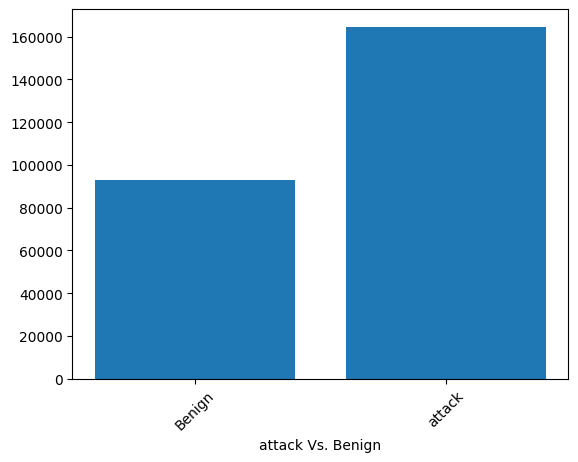

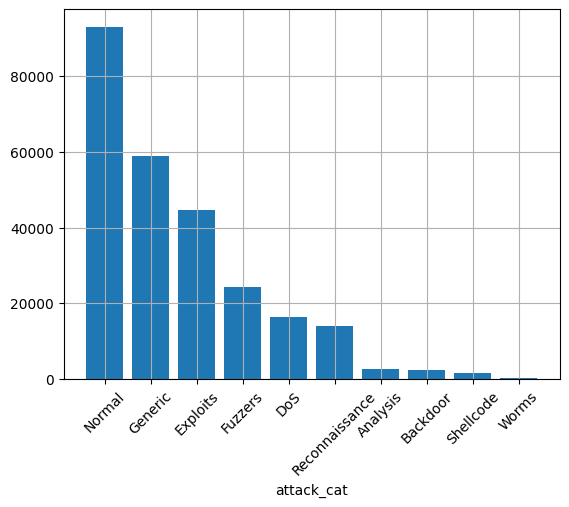

In [12]:
label_category = df['label'].value_counts().sort_index()
plt.bar(['Benign', 'attack'], label_category)
plt.xlabel('attack Vs. Benign')
plt.xticks(rotation = 45)
plt.show()
attack_categories = df['attack_cat'].value_counts()
plt.bar(attack_categories.index, attack_categories)
plt.xlabel('attack_cat')
plt.xticks(rotation = 45)
plt.grid()
plt.show()

### Check the distributsion of near constant features across label and attacks

In [13]:
"trans_depth, response_body_len, is_ftp_login, ct_ftp_cmd, ct_flw_http_mthd, is_sm_ips_ports"

'trans_depth, response_body_len, is_ftp_login, ct_ftp_cmd, ct_flw_http_mthd, is_sm_ips_ports'

In [14]:
print(df.groupby('label')['trans_depth'].value_counts(normalize=True) * 100)
print(df.groupby('attack_cat')['trans_depth'].value_counts(normalize=True).groupby(level=0).head(3) * 100)

label  trans_depth
0      0              90.062366
       1               9.863441
       2               0.074194
1      0              90.174467
       1               9.790312
       2               0.023683
       3               0.002429
       4               0.002429
       5               0.001215
       39              0.001215
       8               0.000607
       9               0.000607
       80              0.000607
       131             0.000607
       155             0.000607
       163             0.000607
       172             0.000607
Name: proportion, dtype: float64
attack_cat      trans_depth
Analysis        0               79.193127
                1               20.806873
Backdoor        0               96.436239
                1                3.477888
                2                0.085874
DoS             0               90.350394
                1                9.606800
                2                0.012230
Exploits        0               76.72768

In [15]:
print(df.groupby('label')['response_body_len'].value_counts(normalize=True).groupby(level = 0).head(3) *100)
print(df.groupby('attack_cat')['response_body_len'].value_counts(normalize=True).groupby(level=0).head(3) * 100)

label  response_body_len
0      0                    90.879570
       3924                  4.096774
       83                    1.009677
1      0                    94.857080
       109                   0.257480
       1663                  0.140278
Name: proportion, dtype: float64
attack_cat      response_body_len
Analysis        0                     79.230482
                138                    1.120657
                156                    1.120657
Backdoor        0                     98.626020
                109                    0.257621
                49                     0.214684
DoS             0                     92.894270
                98                     0.152877
                109                    0.122302
Exploits        0                     86.079730
                109                    0.880404
                1663                   0.518810
Fuzzers         0                     99.748412
                165                    0.024746
        

In [16]:
is_ftp_login_2_4 = df[df['is_ftp_login'].isin([2,4])]
print(is_ftp_login_2_4.groupby('is_ftp_login')['attack_cat'].value_counts())
for feature in ['Exploits', 'Fuzzers', 'Normal']:
    print(feature)
    print(df[df['attack_cat'] == feature]['is_ftp_login'].value_counts())
print("We can conclude is_ftp_login with the values of 2 and 4 are rare so we can drop these rows")
df =df[~df['is_ftp_login'].isin([2, 4])]

is_ftp_login  attack_cat
2             Exploits       4
              Fuzzers        4
              Normal         2
4             Exploits      16
Name: count, dtype: int64
Exploits
is_ftp_login
0    42757
1     1748
4       16
2        4
Name: count, dtype: int64
Fuzzers
is_ftp_login
0    24108
1      134
2        4
Name: count, dtype: int64
Normal
is_ftp_login
0    91684
1     1314
2        2
Name: count, dtype: int64
We can conclude is_ftp_login with the values of 2 and 4 are rare so we can drop these rows


In [17]:
print(df.groupby('label')['is_ftp_login'].value_counts(normalize=True) * 100)
print(df.groupby('attack_cat')['is_ftp_login'].value_counts())
candidate_features_to_delete_on_detection = ['is_ftp_login']

label  is_ftp_login
0      0               98.587066
       1                1.412934
1      0               98.842993
       1                1.157007
Name: proportion, dtype: float64
attack_cat      is_ftp_login
Analysis        0                2677
Backdoor        0                2329
DoS             0               16330
                1                  23
Exploits        0               42757
                1                1748
Fuzzers         0               24108
                1                 134
Generic         0               58871
Normal          0               91684
                1                1314
Reconnaissance  0               13987
Shellcode       0                1511
Worms           0                 174
Name: count, dtype: int64


In [18]:
print(df.groupby('label')['ct_ftp_cmd'].value_counts(normalize=True) * 100)
print(df.groupby('attack_cat')['ct_ftp_cmd'].value_counts(normalize=True).groupby(level=0).head(3) * 100)

label  ct_ftp_cmd
0      0             98.584916
       1              1.408632
       2              0.006452
1      0             98.842993
       1              1.157007
Name: proportion, dtype: float64
attack_cat      ct_ftp_cmd
Analysis        0             100.000000
Backdoor        0             100.000000
DoS             0              99.859353
                1               0.140647
Exploits        0              96.072351
                1               3.927649
Fuzzers         0              99.447240
                1               0.552760
Generic         0             100.000000
Normal          0              98.584916
                1               1.408632
                2               0.006452
Reconnaissance  0             100.000000
Shellcode       0             100.000000
Worms           0             100.000000
Name: proportion, dtype: float64


In [19]:
print(df.groupby('label')['ct_flw_http_mthd'].value_counts(normalize=True) * 100)
print(df.groupby('attack_cat')['ct_flw_http_mthd'].value_counts(normalize=True).groupby(level=0).head(3) * 100)

label  ct_flw_http_mthd
0      0                   90.062152
       1                    8.898041
       4                    0.781737
       9                    0.174197
       2                    0.027958
       12                   0.025807
       16                   0.017205
       6                    0.012904
1      0                   90.174249
       1                    9.310108
       4                    0.362590
       2                    0.040085
       9                    0.032797
       16                   0.019435
       6                    0.018221
       30                   0.018221
       25                   0.015184
       12                   0.007288
       3                    0.001822
Name: proportion, dtype: float64
attack_cat      ct_flw_http_mthd
Analysis        0                    79.193127
                1                     9.787075
                4                     5.379156
Backdoor        0                    96.436239
                1  

In [20]:
print(df.groupby('label')['is_sm_ips_ports'].value_counts(normalize=True) * 100)
print(df.groupby('attack_cat')['is_sm_ips_ports'].value_counts(normalize=True).groupby(level=0).head(3) * 100)
candidate_features_to_delete_on_classification = ['is_sm_ips_ports']

label  is_sm_ips_ports
0      0                   96.045076
       1                    3.954924
1      0                  100.000000
Name: proportion, dtype: float64
attack_cat      is_sm_ips_ports
Analysis        0                  100.000000
Backdoor        0                  100.000000
DoS             0                  100.000000
Exploits        0                  100.000000
Fuzzers         0                  100.000000
Generic         0                  100.000000
Normal          0                   96.045076
                1                    3.954924
Reconnaissance  0                  100.000000
Shellcode       0                  100.000000
Worms           0                  100.000000
Name: proportion, dtype: float64


In [21]:
print(candidate_features_to_delete_on_detection)
print(candidate_features_to_delete_on_classification)

['is_ftp_login']
['is_sm_ips_ports']


## Univariate analysis — numerical features
For each numerical feature:
- What are its minimum, maximum, mean, median, and standard deviation?
- Which numerical features are highly skewed?
- Which features contain potential outliers?
- Which features have unusually large ranges?
- Which features have values close to zero?
- Are there features with many identical values?
- Which numerical features appear approximately normally distributed?
- Which features have right-skewed or left-skewed distributions?
- Are there suspicious or impossible values?

Useful features include:
- dur
- sbytes
- dbytes
- spkts
- dpkts
- rate
- sttl
- dttl
- sload
- dload
- sloss
- dloss
- sinpkt
- dinpkt
- sjit
- djit
- swin
- dwin
- stcpb
- dtcpb

In [22]:
numerical_features_statisics = df.describe()
numerical_features_statisics.loc[['min', 'max', 'mean', '50%', 'std']]

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,175341.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,59.000000,46.000000,65.000000,1.000000,2.000000,30.000000,60.000000,62.000000,1.000000,1.000000
mean,72812.367088,1.246031,19.777541,18.515065,8.573729e+03,1.438864e+04,9.126312e+04,180.010099,84.739811,7.061582e+07,...,5.238621,4.032905,8.323520,0.012494,0.012525,0.132018,6.800347,9.121756,0.014275,0.639049
50%,64417.000000,0.004279,4.000000,2.000000,5.280000e+02,1.780000e+02,2.958580e+03,254.000000,29.000000,7.442672e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
std,48931.107287,5.971942,135.953982,111.991586,1.737826e+05,1.462066e+05,1.603501e+05,102.486910,112.756160,1.857393e+08,...,8.161158,5.831764,11.121173,0.111076,0.111421,0.681887,8.396606,10.875070,0.118624,0.480277


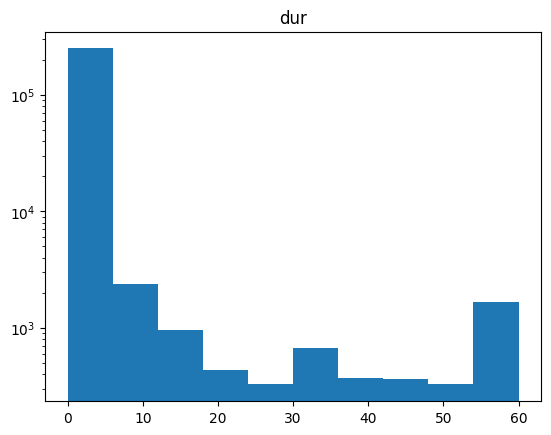

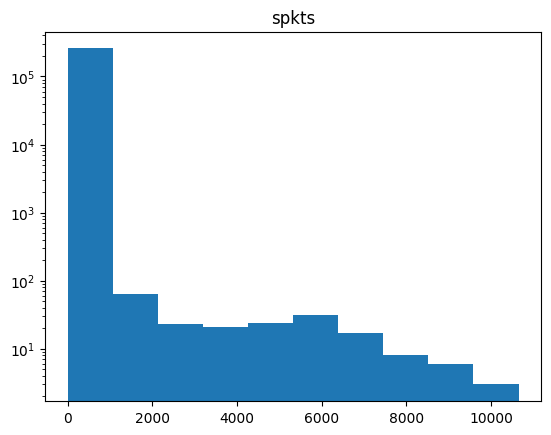

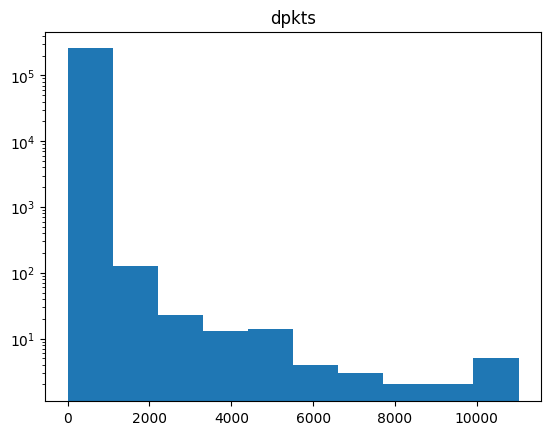

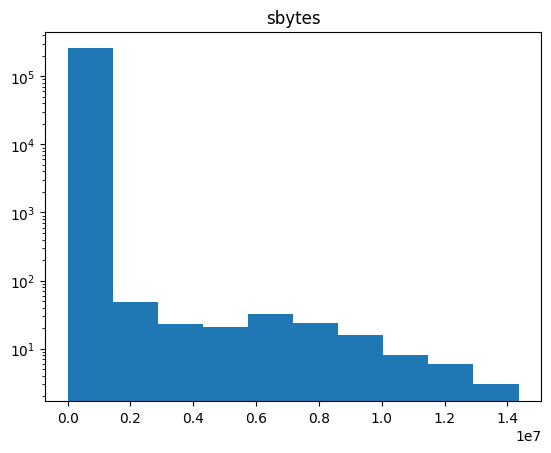

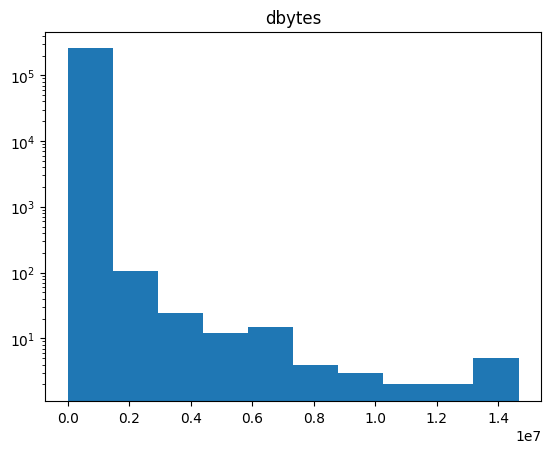

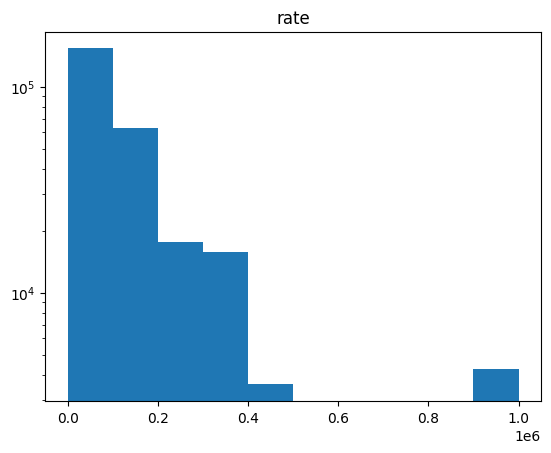

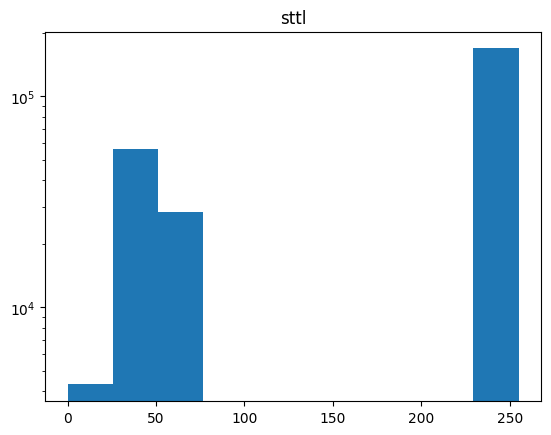

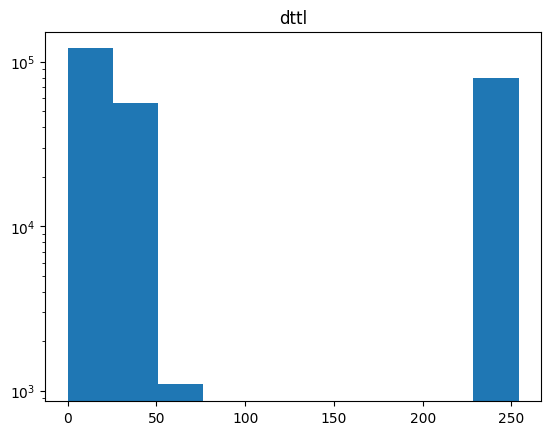

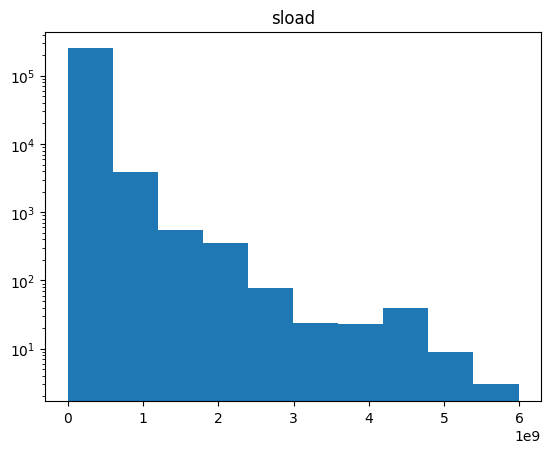

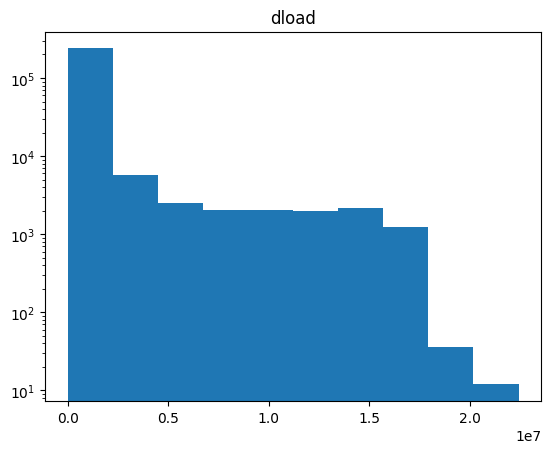

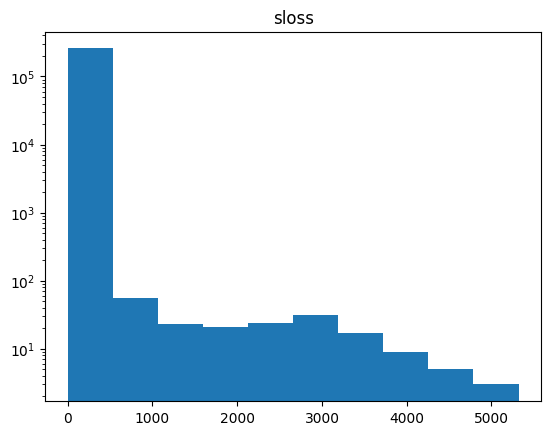

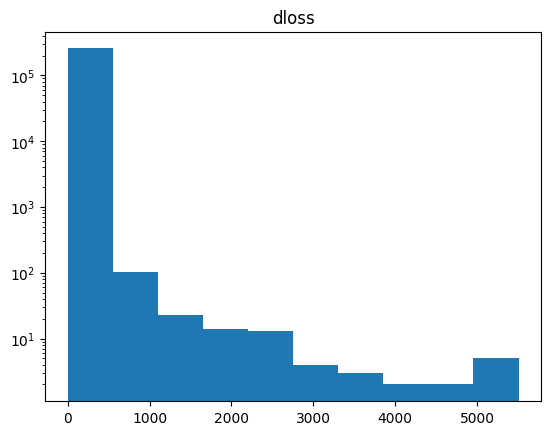

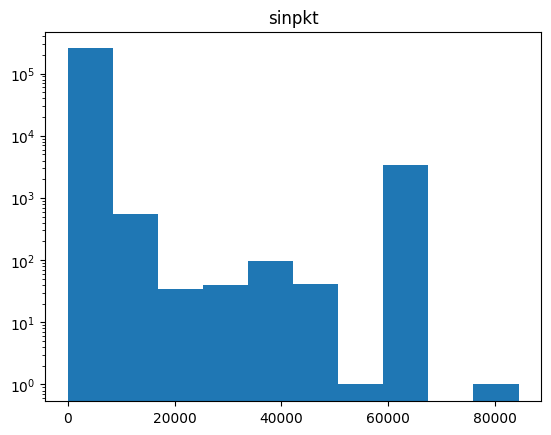

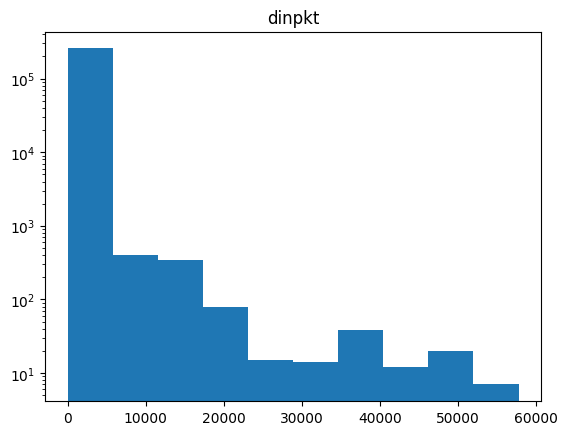

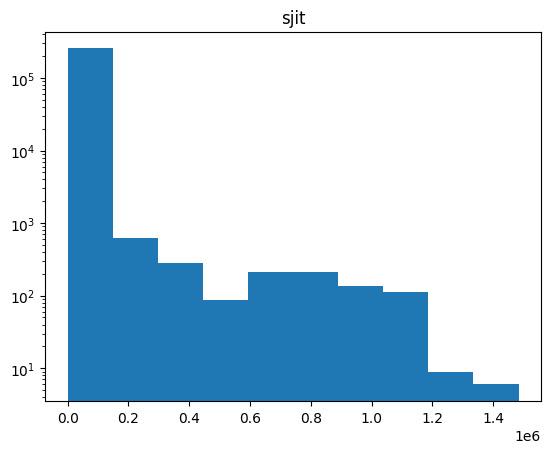

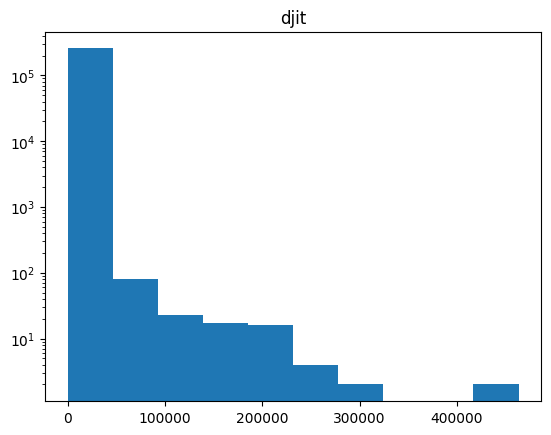

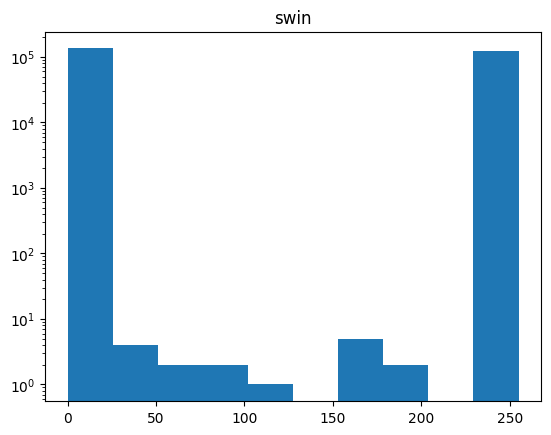

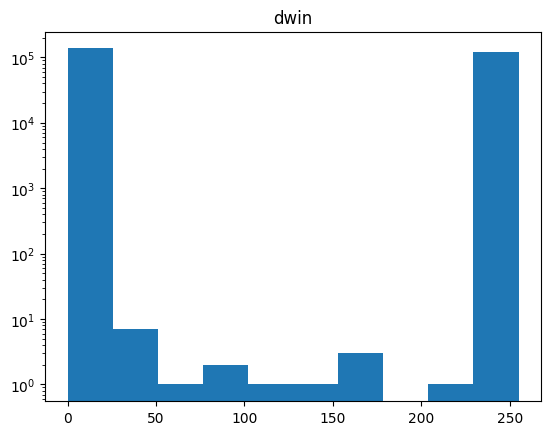

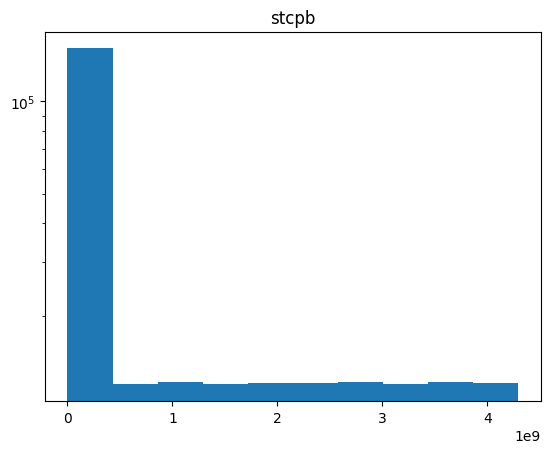

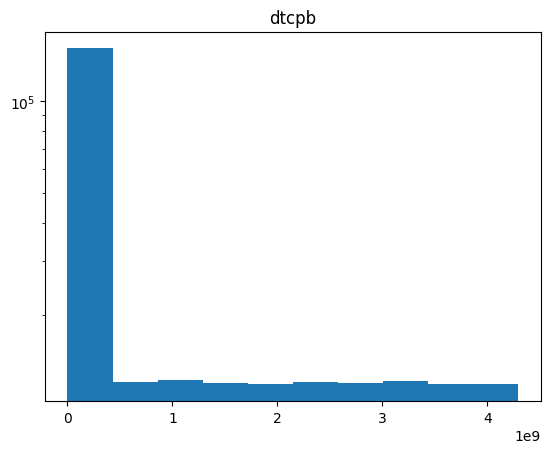

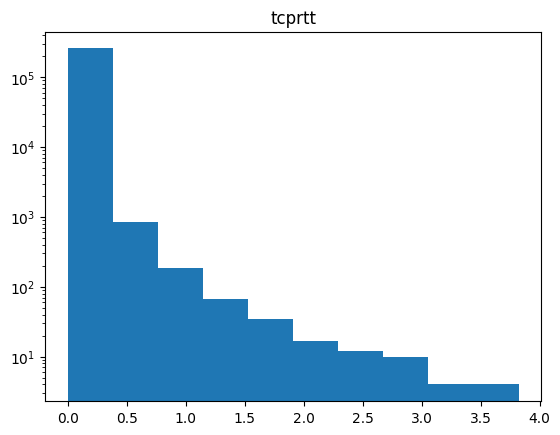

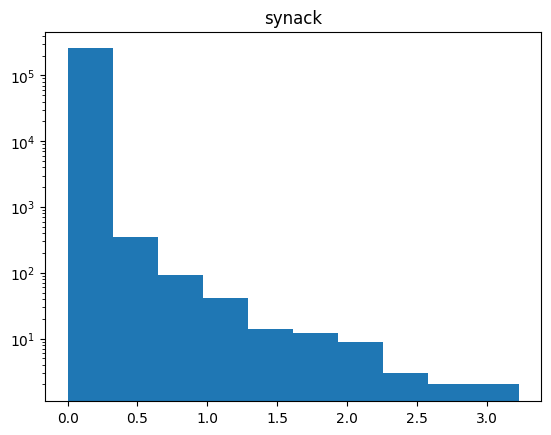

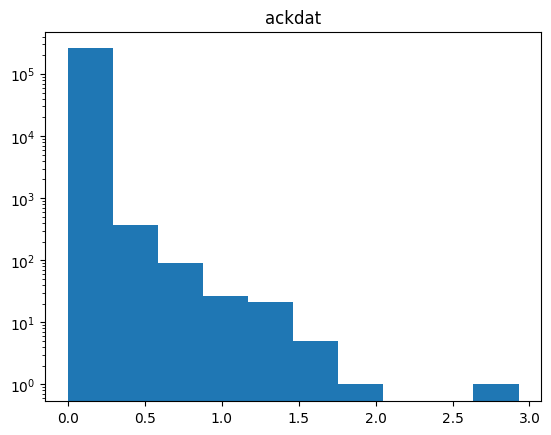

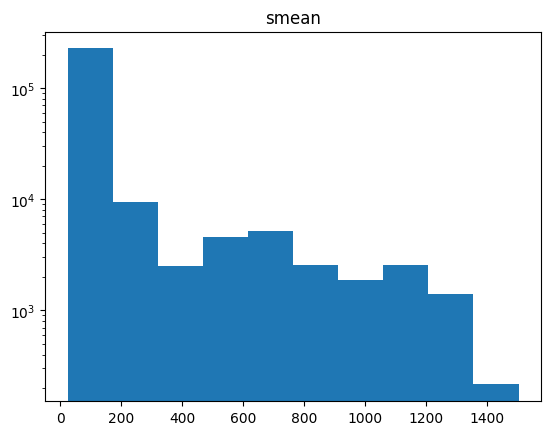

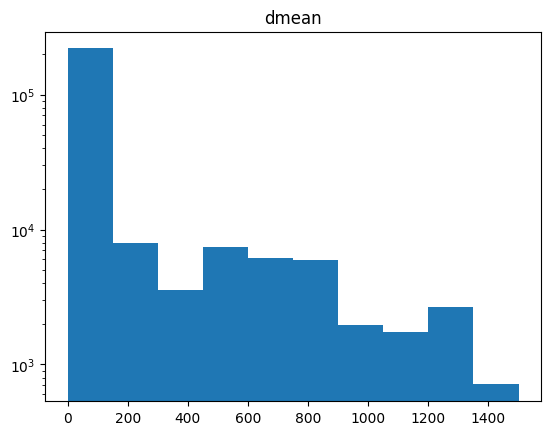

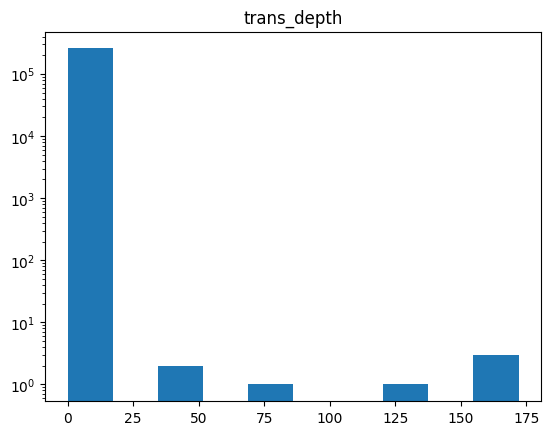

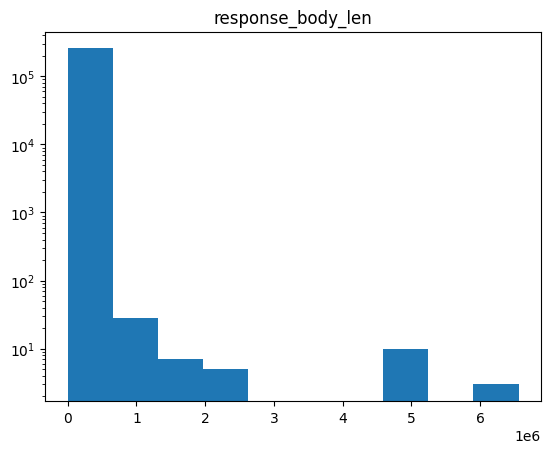

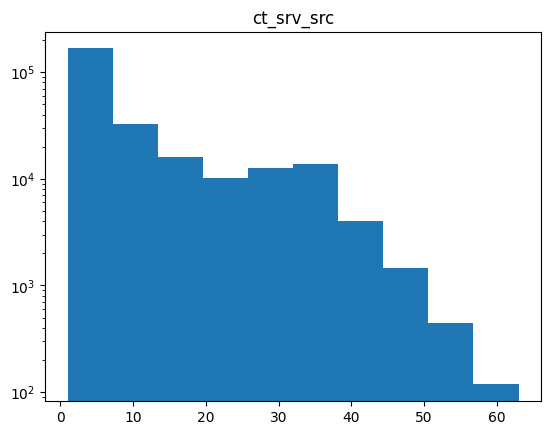

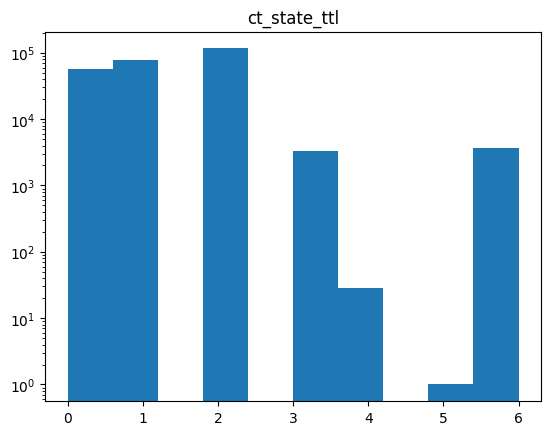

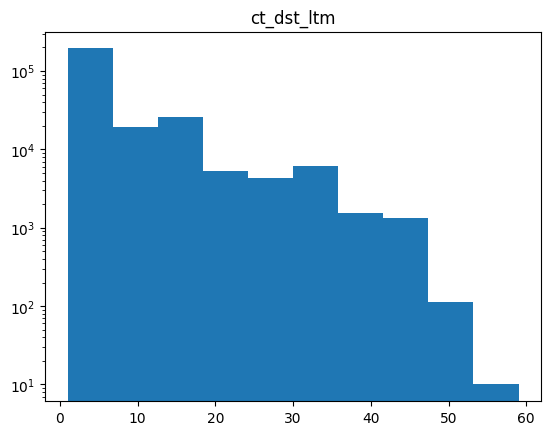

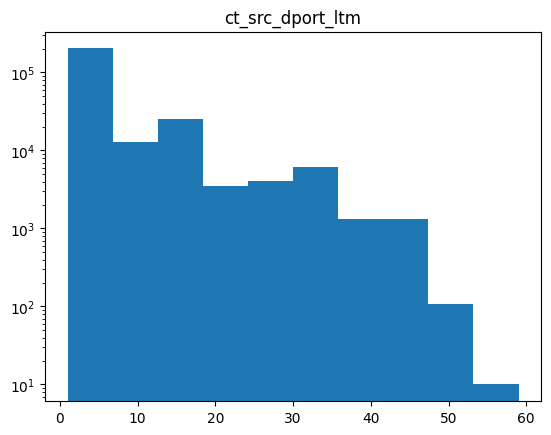

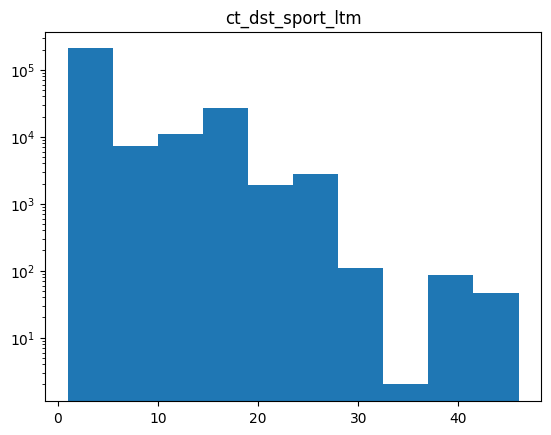

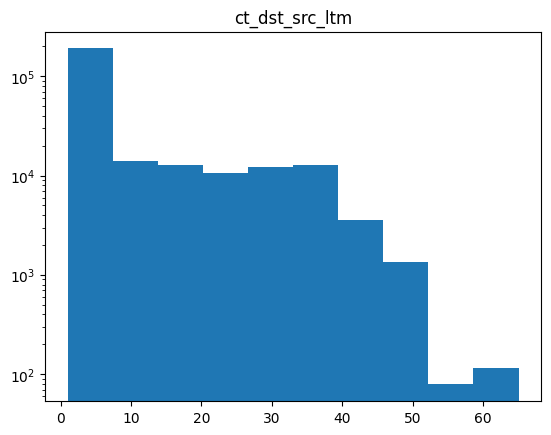

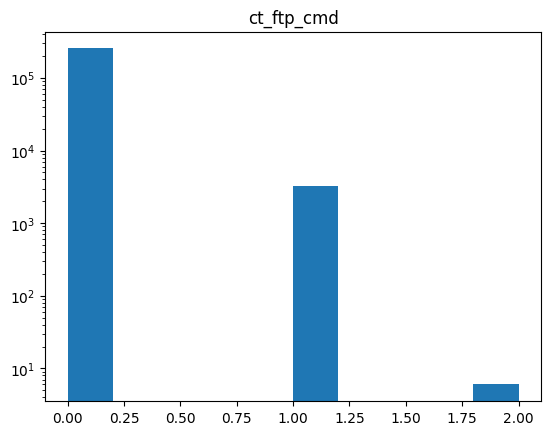

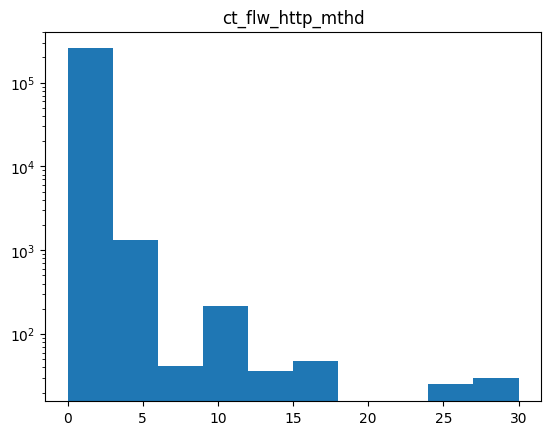

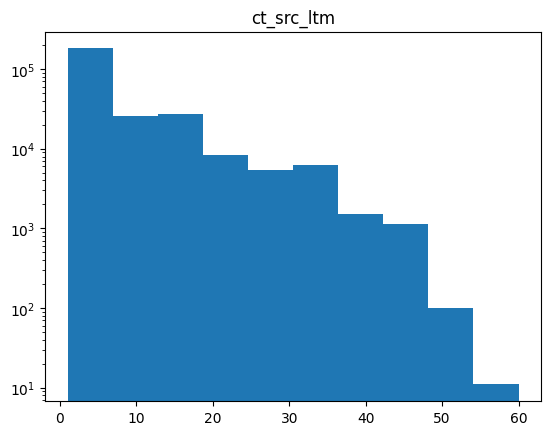

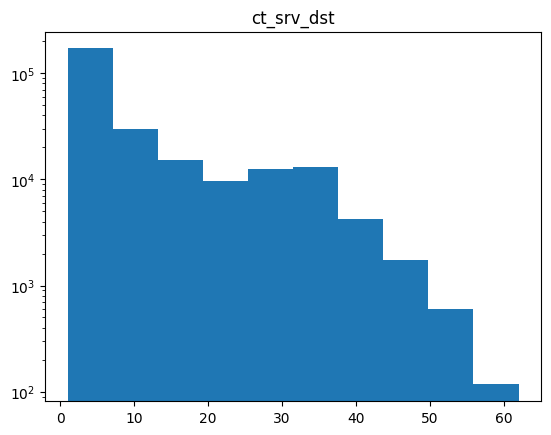

In [23]:
for feature in numerical_features:
    plt.title(feature)
    plt.hist(df[feature])
    plt.yscale('log')
    plt.show()

In [24]:

print("""
the features with highly skewed to right:
- dur
- spkts
- dpkts
- sbytes
- dbytes
- rate
- sload
- dload
- sloss
- dloss
- sinpkt
- dinpkt
- stcpb
- dtcpb
- tcprtt
- synack
- ackdat
- smean
- dmean
- sjit
- djit
- response_body_len
- ct_srv_src
- ct_dst_ltm
- ct_src_dport_ltm
- ct_dst_sport_ltm
- ct_dst_src_ltm
- ct_flw_http_mthd
- ct_src_ltm
- ct_srv_dst
divide these features on bins:
- sttl
- dttl
- swin
- dwin
- trans_depth
- ct_state_ttl
- ct_ftp_cmd
""")


the features with highly skewed to right:
- dur
- spkts
- dpkts
- sbytes
- dbytes
- rate
- sload
- dload
- sloss
- dloss
- sinpkt
- dinpkt
- stcpb
- dtcpb
- tcprtt
- synack
- ackdat
- smean
- dmean
- sjit
- djit
- response_body_len
- ct_srv_src
- ct_dst_ltm
- ct_src_dport_ltm
- ct_dst_sport_ltm
- ct_dst_src_ltm
- ct_flw_http_mthd
- ct_src_ltm
- ct_srv_dst
divide these features on bins:
- sttl
- dttl
- swin
- dwin
- trans_depth
- ct_state_ttl
- ct_ftp_cmd



In [25]:
outliers = []

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    mask = (df[feature] < lower_limit) | (df[feature] > upper_limit)

    temp = df.loc[mask, [feature, 'label']].copy()

    if not temp.empty:
        temp['feature'] = feature
        temp = temp.rename(columns={feature: 'value'})
        outliers.append(temp)
outliers_df = pd.concat(outliers, ignore_index=True)
outliers_df = outliers_df[['feature', 'value', 'label']]

In [26]:
pd.set_option('display.max_rows', None)
outliers_df.groupby('feature')['label'].value_counts(normalize = True) * 100

feature            label
ackdat             1        56.523264
                   0        43.476736
ct_dst_ltm         1        95.715769
                   0         4.284231
ct_dst_sport_ltm   1        99.626897
                   0         0.373103
ct_dst_src_ltm     1        93.986504
                   0         6.013496
ct_flw_http_mthd   1        63.642801
                   0        36.357199
ct_ftp_cmd         1        59.143123
                   0        40.856877
ct_src_dport_ltm   1        96.168442
                   0         3.831558
ct_src_ltm         1        94.647797
                   0         5.352203
ct_srv_dst         1        94.378524
                   0         5.621476
ct_srv_src         1        93.868462
                   0         6.131538
ct_state_ttl       0        67.339888
                   1        32.660112
dbytes             0        73.013692
                   1        26.986308
dinpkt             1        65.999659
                   0        34.000341
djit               1        56.407958
                   0        43.592042
dload              0        87.663974
                   1        12.336026
dloss              0        66.566615
                   1        33.433385
dmean              0        68.986712
                   1        31.013288
dpkts              0        77.141416
                   1        22.858584
dur                1        70.187543
                   0        29.812457
rate               1        93.500701
                   0         6.499299
response_body_len  0        50.038346
                   1        49.961654
sbytes             0        62.243502
                   1        37.756498
sinpkt             1        56.569882
                   0        43.430118
sjit               1        53.774868
                   0        46.225132
sload              1        84.269765
                   0        15.730235
sloss              0        55.488740
                   1        44.511260
smean              1        55.122041
                   0        44.877959
spkts              0        70.549261
                   1        29.450739
synack             1        55.608681
                   0        44.391319
tcprtt             1        53.880141
                   0        46.119859
trans_depth        1        63.645661
                   0        36.354339
Name: proportion, dtype: float64

In [27]:
difference_range = []
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    feature_range = numerical_features_statisics[feature]['max'] - numerical_features_statisics[feature]['min']
    difference_range.append({
        'feature':feature,
        'difference':feature_range - IQR,
        'range':feature_range,
        'IQR':IQR,
        'ratio': feature_range/IQR if IQR !=0 else np.nan
    })
difference_range = pd.DataFrame(difference_range)
difference_range.sort_values(by = 'ratio', ascending=False)

,feature,difference,range,IQR,ratio
4,dbytes,1.465647e+07,1.465753e+07,1.064000e+03,13775.875000
3,sbytes,1.435450e+07,1.435575e+07,1.248000e+03,11503.004808
15,djit,4.630796e+05,4.631992e+05,1.196766e+02,3870.424413
11,dloss,5.505000e+03,5.507000e+03,2.000000e+00,2753.500000
10,sloss,5.316000e+03,5.319000e+03,3.000000e+00,1773.000000
12,sinpkt,8.431342e+04,8.437150e+04,5.807318e+01,1452.847810
2,dpkts,1.100800e+04,1.101800e+04,1.000000e+01,1101.800000
1,spkts,1.063500e+04,1.064500e+04,1.000000e+01,1064.500000
13,dinpkt,5.768282e+04,5.773924e+04,5.642213e+01,1023.343791
9,dload,2.240061e+07,2.242273e+07,2.211876e+04,1013.742823


### Bin some descrete numerical features

In [28]:
numerical_features_to_bin = ['sttl', 'dttl', 'swin', 'dwin', 'trans_depth', 'ct_state_ttl', 'ct_ftp_cmd']

#### sttl

In [29]:
df['sttl'].value_counts().sort_index()

,count
sttl,
0,4210
1,102
29,52
30,2
31,56155
32,19
60,30
62,28035
63,33


Before Binning


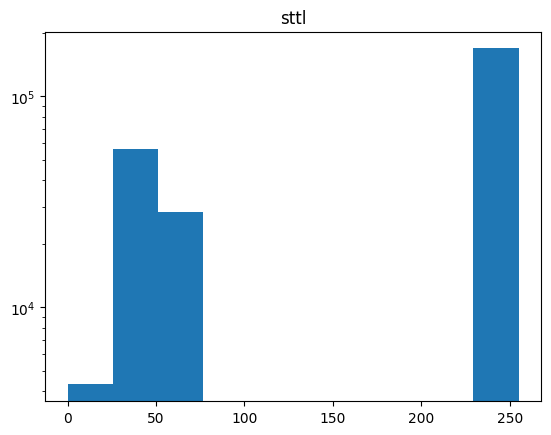

After Binning


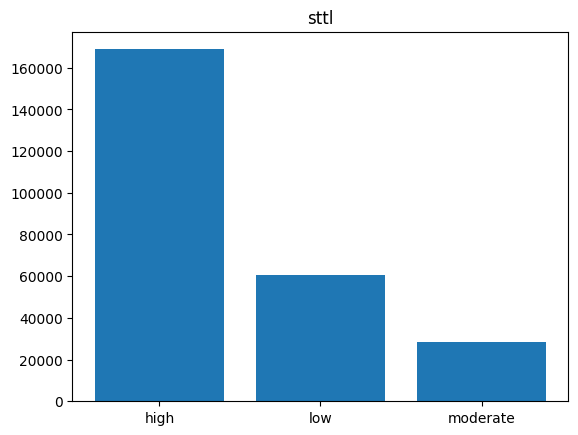

In [30]:
sttl_bins = [-1, 60, 64, 255]
sttl_labels = ['low', 'moderate', 'high']
print("Before Binning")
plt.title('sttl')
plt.hist(df['sttl'])
plt.yscale('log')
plt.show()
df['sttl'] = pd.cut(df['sttl'], bins=sttl_bins, labels=sttl_labels)
print("After Binning")
plt.title('sttl')
plt.bar(df['sttl'].value_counts().index, df['sttl'].value_counts())
plt.show()

### dttl

In [31]:
df['dttl'].value_counts().sort_index()

,count
dttl,
0,120439
29,56121
30,43
31,38
32,4
60,1092
252,79899
253,9
254,2


Before Binning


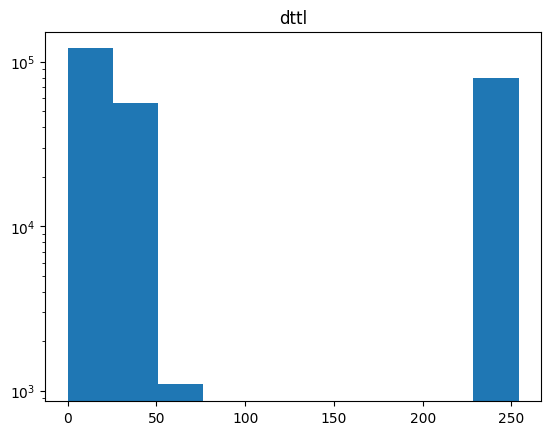

After Binning


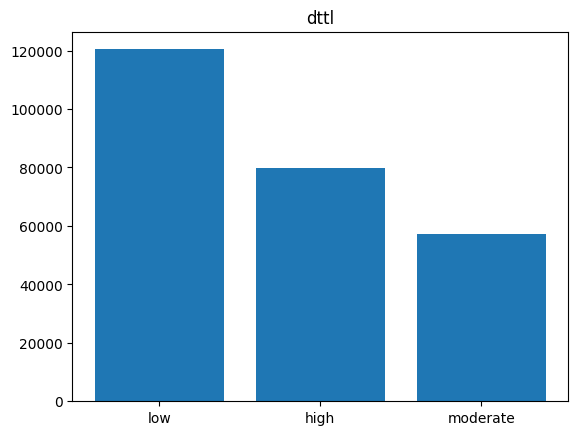

In [32]:
dttl_bins = [-1, 20, 60, 255]
dttl_labels = ['low', 'moderate', 'high']
print("Before Binning")
plt.title('dttl')
plt.hist(df['dttl'])
plt.yscale('log')
plt.show()
df['dttl'] = pd.cut(df['dttl'], bins=dttl_bins, labels=dttl_labels)
print("After Binning")
plt.title('dttl')
plt.bar(df['dttl'].value_counts().index, df['dttl'].value_counts())
plt.show()

#### swin

In [33]:
df['swin'].value_counts().sort_index()

,count
swin,
0,134632
5,1
14,1
31,1
42,1
43,1
45,1
52,1
67,1


Before Binning


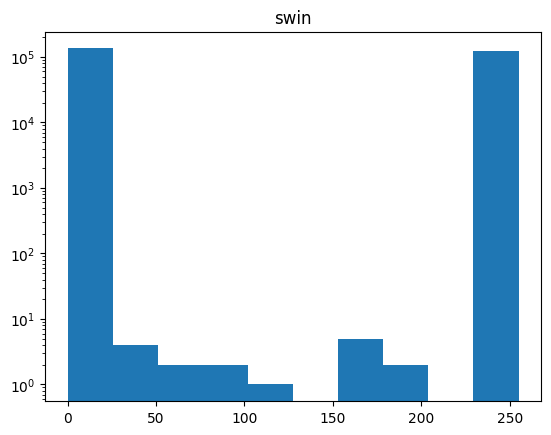

After Binning


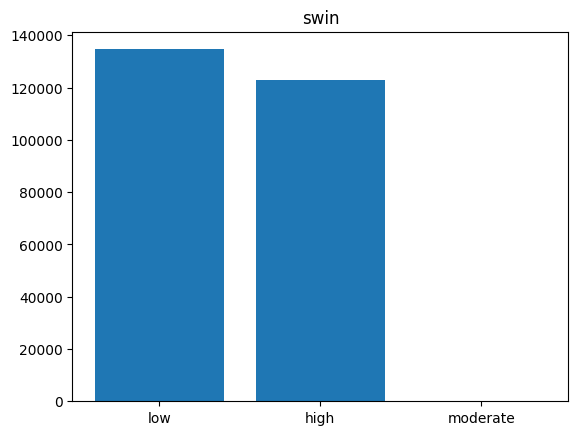

In [34]:
swin_bins = [-1, 0, 254, 255]
swin_labels = ['low', 'moderate', 'high']
print("Before Binning")
plt.title('swin')
plt.hist(df['swin'])
plt.yscale('log')
plt.show()
df['swin'] = pd.cut(df['swin'], bins=swin_bins, labels=swin_labels)
print("After Binning")
plt.title('swin')
plt.bar(df['swin'].value_counts().index, df['swin'].value_counts())
plt.show()

#### dwin

In [35]:
df['dwin'].value_counts().sort_index()

,count
dwin,
0,137157
12,1
27,2
33,1
37,1
40,1
46,1
48,1
70,1


Before Binning


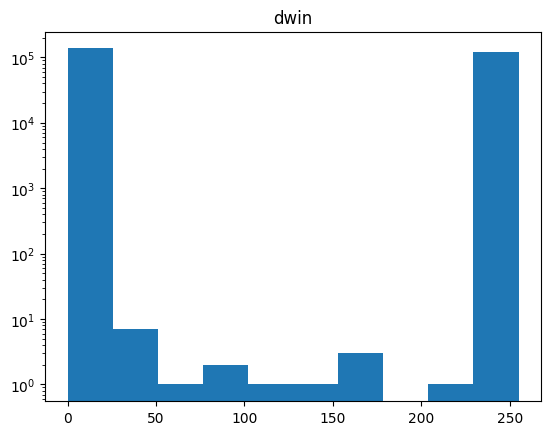

After Binning


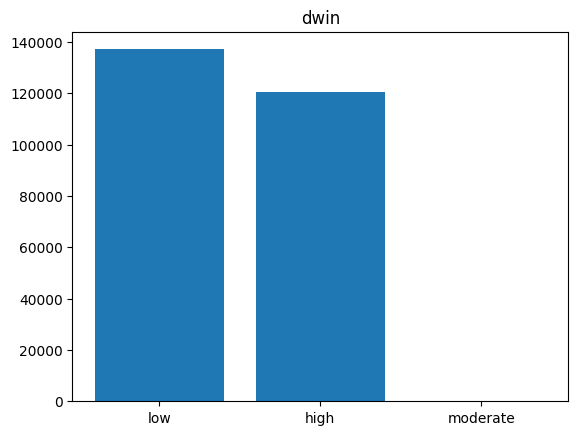

In [36]:
dwin_bins = [-1, 0, 254, 255]
dwin_labels = ['low', 'moderate', 'high']
print("Before Binning")
plt.title('dwin')
plt.hist(df['dwin'])
plt.yscale('log')
plt.show()
df['dwin'] = pd.cut(df['dwin'], bins=dwin_bins, labels=dwin_labels)
print("After Binning")
plt.title('dwin')
plt.bar(df['dwin'].value_counts().index, df['dwin'].value_counts())
plt.show()

#### ct_state_ttl

In [37]:
df['ct_state_ttl'].value_counts().sort_index()

,count
ct_state_ttl,
0,57834
1,76573
2,116154
3,3323
4,28
5,1
6,3734


Before Binning


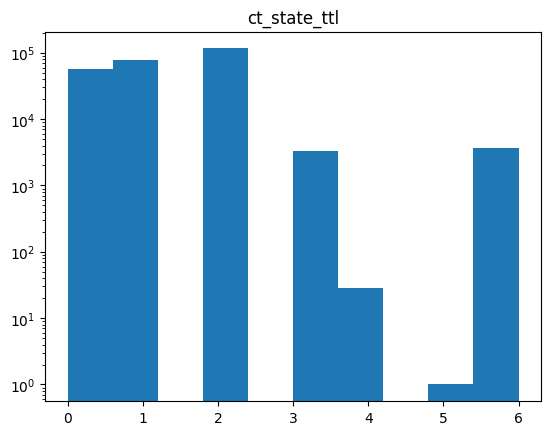

After Binning


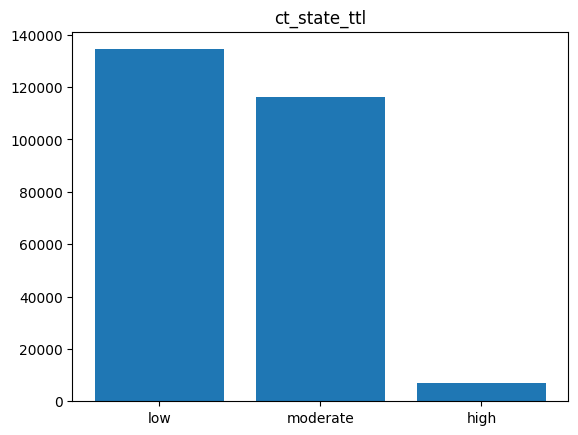

In [38]:
ct_state_ttl_bins = [-1, 1, 2, 6]
ct_state_ttl_labels = ['low', 'moderate', 'high']
print("Before Binning")
plt.title('ct_state_ttl')
plt.hist(df['ct_state_ttl'])
plt.yscale('log')
plt.show()
df['ct_state_ttl'] = pd.cut(df['ct_state_ttl'], bins=ct_state_ttl_bins, labels=ct_state_ttl_labels)
print("After Binning")
plt.title('ct_state_ttl')
plt.bar(df['ct_state_ttl'].value_counts().index, df['ct_state_ttl'].value_counts())
plt.show()

In [39]:
categorical_features = [categorical_features + ['sttl', 'dttl', 'swin', 'dwin', 'ct_state_ttl', 'ct_ftp_cmd']]

In [40]:
numerical_features = [feature for feature in numerical_features if feature not in ['sttl', 'dttl', 'swin', 'dwin', 'ct_state_ttl', 'ct_ftp_cmd']]

## Categorical analysis
For columns such as:
- proto
- service
- state
- attack_cat

Ask:
- What are the most frequent protocols?
- What are the most common services?
- What are the most common connection states?
- Which attack categories are most common?
- Which attack categories are rare?
- How imbalanced is the target?
- Are some protocols strongly associated with specific attack categories?
- Are some services used predominantly by attacks?

In [41]:
print(f"""
the most frequency protocols:
{df['proto'].value_counts().nlargest(5)}
""")


the most frequency protocols:
proto
tcp     123015
udp      92701
unas     15599
arp       3846
ospf      3271
Name: count, dtype: int64



In [42]:
print(f"""
the most frequent services:
{df['service'].value_counts().nlargest(5)}
""")


the most frequent services:
service
-           141321
dns          68661
http         27011
smtp          6909
ftp-data      5391
Name: count, dtype: int64



In [43]:
print(f"""
the most frequent states:
{df['state'].value_counts().nlargest(5)}
""")


the most frequent states:
state
FIN    117146
INT    116438
CON     20126
REQ      3833
RST        84
Name: count, dtype: int64



In [44]:
print(f"""
the most frequent attacks:
{df['attack_cat'].value_counts().nlargest(5)}
""")


the most frequent attacks:
attack_cat
Normal      92998
Generic     58871
Exploits    44505
Fuzzers     24242
DoS         16353
Name: count, dtype: int64



In [45]:
print(f"""
the rarest attacks:
{df['attack_cat'].value_counts().nsmallest(5)}
""")


the rarest attacks:
attack_cat
Worms               174
Shellcode          1511
Backdoor           2329
Analysis           2677
Reconnaissance    13987
Name: count, dtype: int64



In [46]:
attacks = (df['attack_cat'].value_counts(normalize=True) * 100).round(2)
print(f"""
The difference between the most frequent and rarest classes is {attacks.max() - attacks.min()}
percentage points, indicating a substantial class imbalance.
""")


The difference between the most frequent and rarest classes is 36.03
percentage points, indicating a substantial class imbalance.



In [47]:
attacks_proto = df.groupby('attack_cat')['proto'].value_counts(normalize = True) * 100
print(f"""
{attacks_proto.groupby(level = 0).head(2)}
We can conclude that:
- UDP is strongly associated with Generic attacks, accounting for 97.73% of Generic samples.
- TCP is strongly associated with Worms and Normal traffic, accounting for 87.93% and 72.01% respectively.
- TCP also dominates Exploits and Fuzzers, representing 61.62% and 63.81% of their samples.
- Shellcode attacks show a nearly equal distribution between UDP and TCP, suggesting no strong preference for either protocol.
""")


attack_cat      proto
Analysis        unas     34.590960
                tcp      23.234965
Backdoor        unas     34.607128
                tcp      13.868613
DoS             unas     32.079741
                tcp      20.399927
Exploits        tcp      61.617796
                unas     14.677003
Fuzzers         tcp      63.814867
                udp      24.927811
Generic         udp      97.725535
                tcp       1.708821
Normal          tcp      72.009075
                udp      23.676853
Reconnaissance  tcp      49.796239
                udp      34.961035
Shellcode       udp      50.363997
                tcp      49.636003
Worms           tcp      87.931034
                udp      12.068966
Name: proportion, dtype: float64
We can conclude that:
- UDP is strongly associated with Generic attacks, accounting for 97.73% of Generic samples.
- TCP is strongly associated with Worms and Normal traffic, accounting for 87.93% and 72.01% respectively.
- TCP also dominates E

In [48]:
attacks_service = df.groupby('attack_cat')['service'].value_counts(normalize = True) * 100
print(f"""
{attacks_service.groupby(level = 0).head(2)}
We can conclude that:
- 'no service' dominates 'Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Normal', 'Reconnaissance', 'Shellcode'
- 'dns' dominates 'Genetic'
- 'http' dominates 'Worms'
""")


attack_cat      service
Analysis        -           78.931640
                http        20.844229
Backdoor        -           95.276943
                http         3.950193
DoS             -           84.663365
                http        10.450682
Exploits        -           51.780699
                http        25.797101
Fuzzers         -           90.669087
                http         4.483953
Generic         dns         97.294084
                -            1.554246
Normal          -           68.697176
                dns         11.356158
Reconnaissance  -           84.221062
                http        14.820905
Shellcode       -          100.000000
Worms           http        85.057471
                -           14.942529
Name: proportion, dtype: float64
We can conclude that:
- 'no service' dominates 'Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Normal', 'Reconnaissance', 'Shellcode'
- 'dns' dominates 'Genetic'
- 'http' dominates 'Worms'



## Attack vs Normal
- How many observations are Normal vs Attack?
- Which numerical features differ most between Normal and Attack traffic?
- Do attacks generally have longer or shorter dur?
- Do attacks transfer more or fewer bytes (sbytes, dbytes)?
- Do attacks generate more packets (spkts, dpkts)?
- Is rate different between Normal and Attack traffic?
- Are TTL values (sttl, dttl) different between Normal and Attack traffic?
- Are loading features (sload, dload) different between Normal and Attack traffic?
- Which features appear most useful for distinguishing Normal from Attack?

In [49]:
df['label'].value_counts()

,count
label,
1,164649
0,92998


In [50]:
comparison = df.groupby('label')[numerical_features].median().T
comparison['difference'] = (comparison[0] - comparison[1]).abs()/comparison[0]
comparison.nlargest(10, columns='difference')

label,0,1,difference
rate,642.836867,1.111111e+05,171.844952
sload,298197.859400,5.066666e+07,168.909550
dpkts,8.000000,0.000000e+00,1.000000
dbytes,642.000000,0.000000e+00,1.000000
dload,75920.273440,0.000000e+00,1.000000
sloss,2.000000,0.000000e+00,1.000000
dloss,2.000000,0.000000e+00,1.000000
dinpkt,1.030147,0.000000e+00,1.000000
sjit,74.661079,0.000000e+00,1.000000
djit,21.156920,0.000000e+00,1.000000


In [51]:
print(f"""
{df.groupby('label')['dur'].median()}
Attacks generally have shorter durations than normal traffic. The median duration
is approximately 0.000009 for attacks compared with 0.053936 for normal traffic.
""")


label
0    0.053936
1    0.000009
Name: dur, dtype: float64
Attacks generally have shorter durations than normal traffic. The median duration
is approximately 0.000009 for attacks compared with 0.053936 for normal traffic.



In [52]:
df_bytes = pd.DataFrame()
df_bytes['tbytes'] = df['sbytes'] + df['dbytes']
df_bytes['label'] = df['label']
print(f"""
{df_bytes.groupby('label').median()}
Attack traffic generally transfers fewer total bytes than normal traffic.
""")


       tbytes
label        
0      2014.0
1       200.0
Attack traffic generally transfers fewer total bytes than normal traffic.



In [53]:
df_pkts = pd.DataFrame()
df_pkts['tpkts'] = df['spkts'] + df['dpkts']
df_pkts['label'] = df['label']
print(f"""
{df_pkts.groupby('label').median()}
Attack traffic generates fewer total packets than normal traffic.
""")


       tpkts
label       
0       18.0
1        2.0
Attack traffic generates fewer total packets than normal traffic.



In [54]:
#Is rate different between Normal and Attack traffic?
print(f"""
{df.groupby('label')['rate'].median()}
attacks have a higher traffic rate than normal traffic.
""")


label
0       642.836867
1    111111.107200
Name: rate, dtype: float64
attacks have a higher traffic rate than normal traffic.



In [55]:
#Are TTL values (sttl, dttl) different between Normal and Attack traffic?
# print(f"""
# {df.groupby('label')['sttl'].median()}
# attacks have a higher sttl than normal traffic.
# """)
# print(f"""
# {df.groupby('label')['dttl'].median()}
# attacks have a lower dttl than normal traffic.
# """)

In [56]:
#Are loading features (sload, dload) different between Normal and Attack traffic?
print(f"""
{df.groupby('label')['sload'].median()}
attacks have a higher sload than normal traffic.
""")

print(f"""
{df.groupby('label')['dload'].median()}
attacks have a lower dload than normal traffic.
""")


label
0    2.981979e+05
1    5.066666e+07
Name: sload, dtype: float64
attacks have a higher sload than normal traffic.


label
0    75920.27344
1        0.00000
Name: dload, dtype: float64
attacks have a lower dload than normal traffic.



In [57]:
#Which features appear most useful for distinguishing Normal from Attack?
print("""
Based on the EDA, the following numerical features appear most useful for distinguishing
Normal from Attack traffic. They were selected based on either large differences in median
values or noticeable differences in outlier behavior between the two classes:
- sbytes & dbytes
- spkts & dpkts
- sttl & dttl
- sload & dload
- ct_dst_ltm
- ct_dst_sport_ltm
- ct_dst_src_ltm
- ct_src_dport_ltm
- ct_src_ltm
- ct_srv_dst
- ct_srv_src
- rate
""")


Based on the EDA, the following numerical features appear most useful for distinguishing
Normal from Attack traffic. They were selected based on either large differences in median
values or noticeable differences in outlier behavior between the two classes:
- sbytes & dbytes
- spkts & dpkts
- sttl & dttl
- sload & dload
- ct_dst_ltm
- ct_dst_sport_ltm
- ct_dst_src_ltm
- ct_src_dport_ltm
- ct_src_ltm
- ct_srv_dst
- ct_srv_src
- rate



## Attack-category analysis
- Which attack category occurs most frequently?
- Which attack category occurs least frequently?
- How does the distribution of dur differ between attack categories?
- How does sbytes differ across attack categories?
- How does dbytes differ across attack categories?
- Which attack categories generate the most packets?
- Which attack categories have the highest rate?
- Which attack categories have unusually high sload or dload?
- Which features appear to distinguish different attack categories?

In [58]:
attacks_cats = df[df['attack_cat'] != 'Normal']['attack_cat'].value_counts()
print(f"""
the attack category that occurs
- most frequently: {attacks_cats.idxmax()} with {attacks_cats.max()} records
- least frequently: {attacks_cats.idxmin()} with {attacks_cats.min()} records
""")


the attack category that occurs
- most frequently: Generic with 58871 records
- least frequently: Worms with 174 records



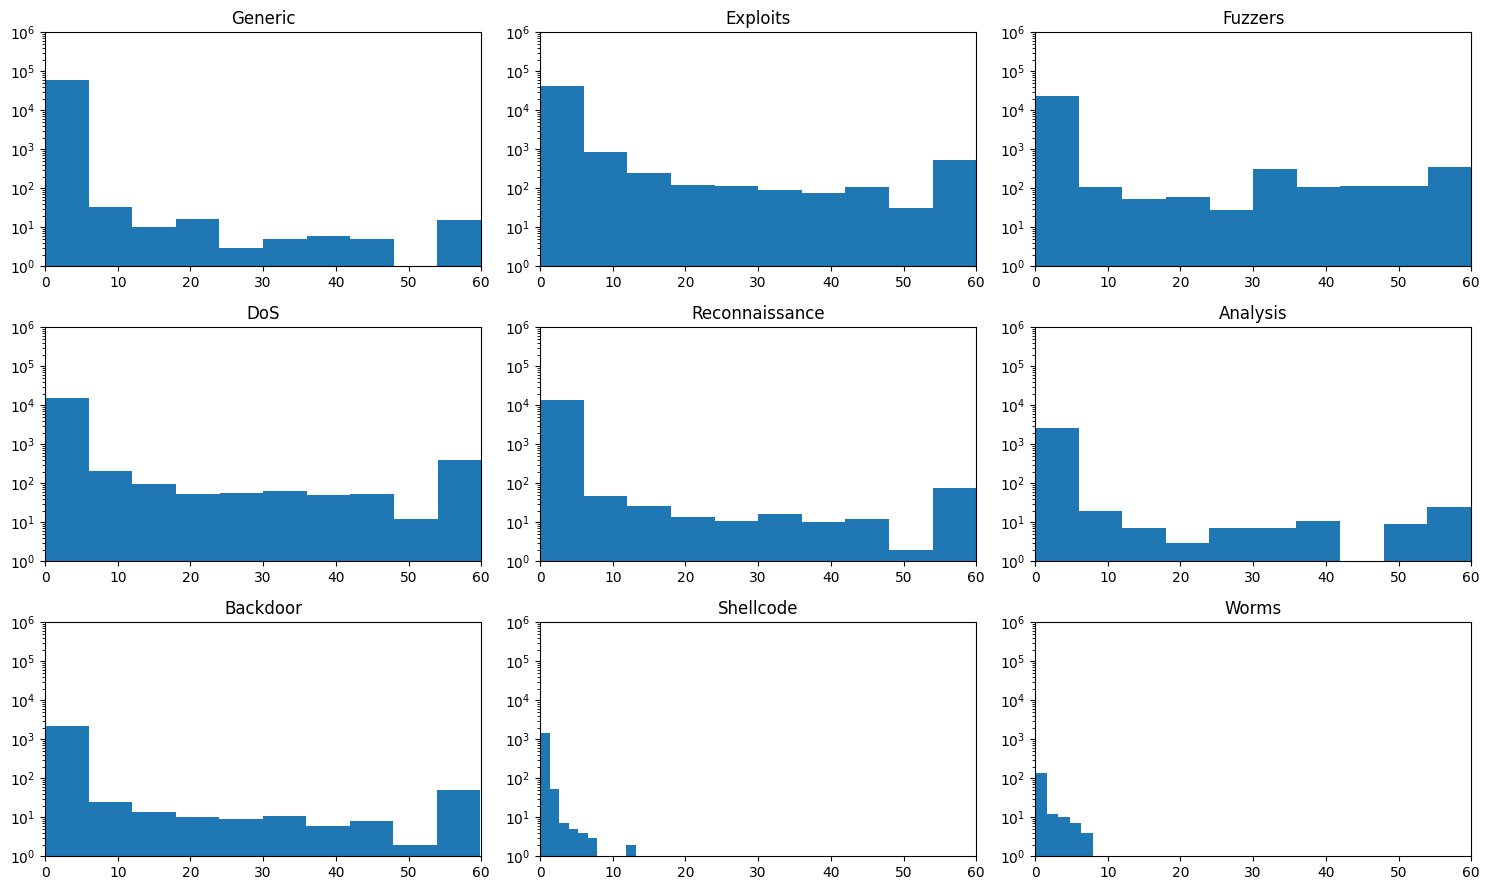


Seven of the nine categories — Generic, Exploits, Fuzzers, DoS, Reconnaissance, Analysis, and Backdoor — exhibit a nearly identical distribution
shape:a sharp spike of very short-duration attacks (0–5 seconds), a steep drop-off, a long sparse tail through the mid-range, and a small secondary
cluster near the 55–60 second mark. Shellcode and Worms deviate from this pattern: both cut off entirely by roughly 10–15 seconds, have no long-duration
tail, and show substantially lower overall record counts than the other seven categories.



In [59]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for i, attack in enumerate(attacks_cats.index):
    ax = axes.flat[i]
    ax.set_title(attack)
    ax.hist(df[df['attack_cat'] == attack]['dur'])
    ax.set_yscale('log')
    ax.set_ylim(1, 10e+5)
    ax.set_xlim(0, 60)
plt.tight_layout()
plt.show()

print(f"""
Seven of the nine categories — Generic, Exploits, Fuzzers, DoS, Reconnaissance, Analysis, and Backdoor — exhibit a nearly identical distribution
shape:a sharp spike of very short-duration attacks (0–5 seconds), a steep drop-off, a long sparse tail through the mid-range, and a small secondary
cluster near the 55–60 second mark. Shellcode and Worms deviate from this pattern: both cut off entirely by roughly 10–15 seconds, have no long-duration
tail, and show substantially lower overall record counts than the other seven categories.
""")

In [60]:
# How does sbytes differ across attack categories?
df_attack_cats = df[df['attack_cat'] != 'Normal']
print(f"""
{df_attack_cats.groupby('attack_cat')['sbytes'].median().sort_values(ascending = False)}
""")


attack_cat
Worms             1302.0
Exploits           842.0
Fuzzers            820.0
Reconnaissance     564.0
Shellcode          536.0
Analysis           200.0
DoS                200.0
Backdoor           200.0
Generic            114.0
Name: sbytes, dtype: float64



In [61]:
# How does dbytes differ across attack categories?
print(f"""
{df_attack_cats.groupby('attack_cat')['dbytes'].median().sort_values(ascending = False)}
""")


attack_cat
Exploits          354.0
Worms             268.0
Fuzzers           268.0
Reconnaissance     96.0
Analysis            0.0
Backdoor            0.0
DoS                 0.0
Generic             0.0
Shellcode           0.0
Name: dbytes, dtype: float64



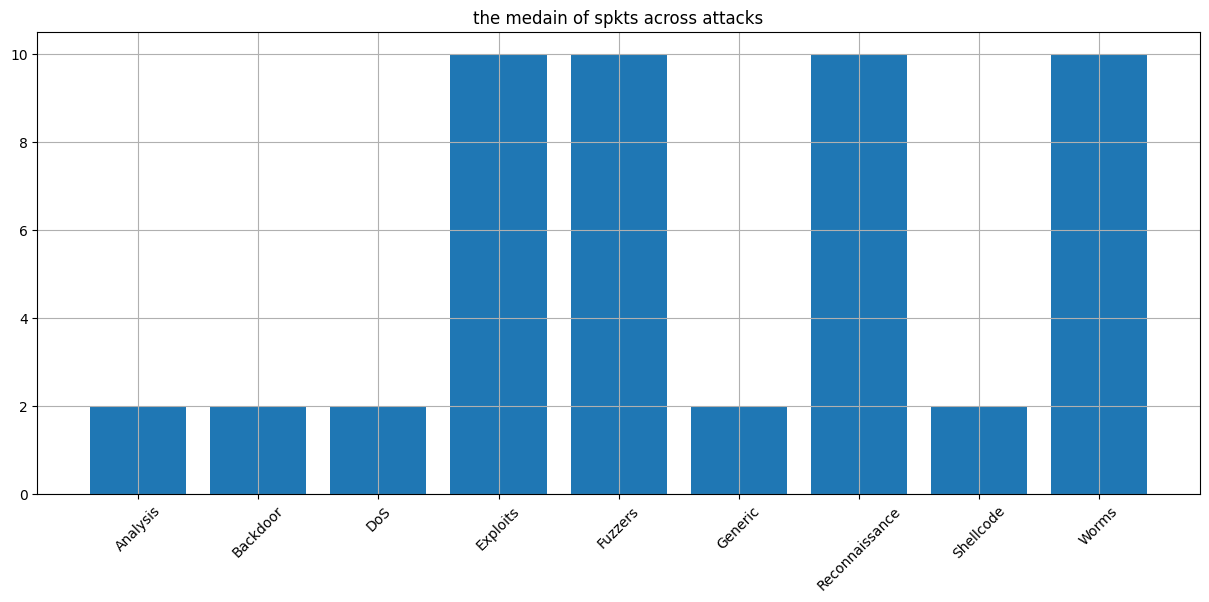

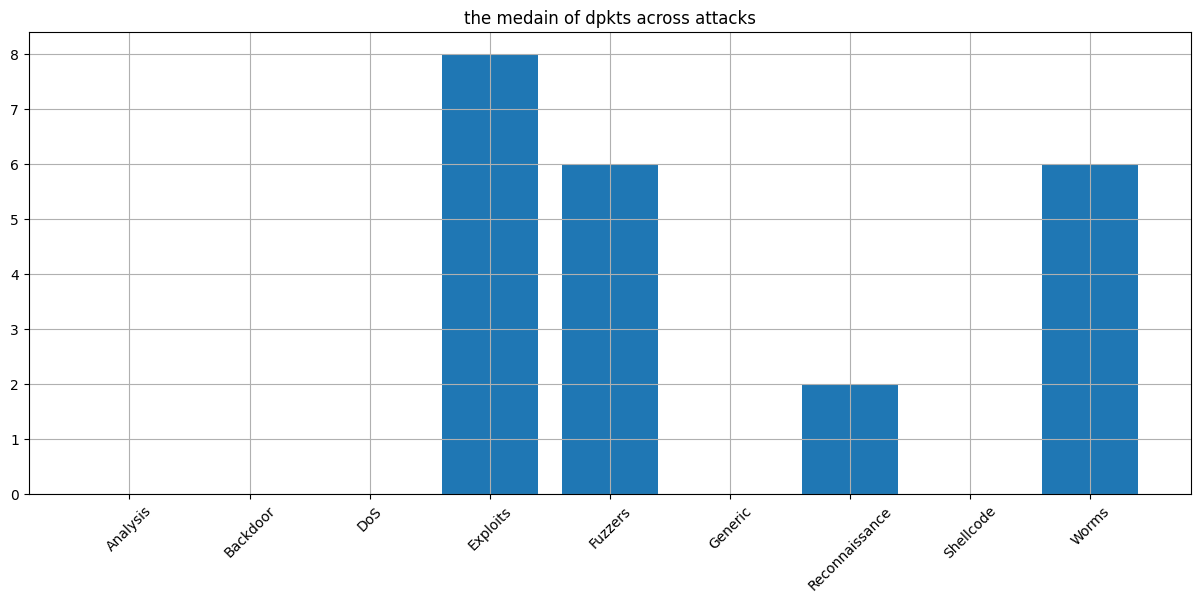

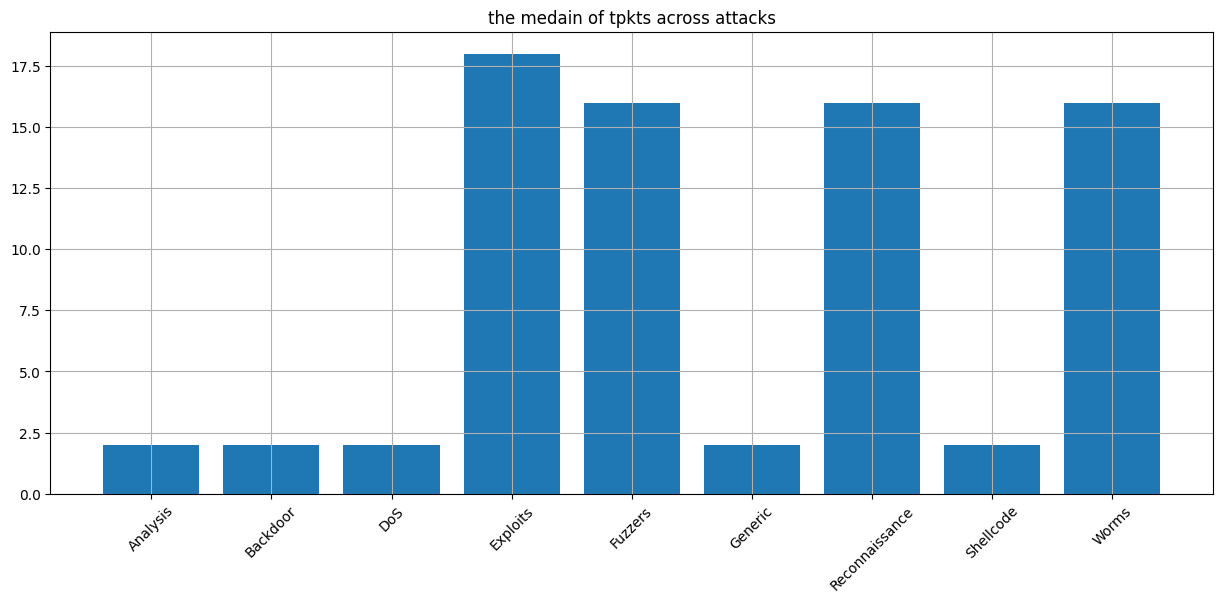

Exploits attacks generate the highest total and destination packet counts, though several categories (Fuzzers, Reconnaissance, Worms) generate
comparable source packet volumes.



In [62]:
#Which attack categories generate the most packets?Which attack categories generate the most packets?
df_attacks_pkts = pd.DataFrame()
df_attacks_pkts['spkts'] = df['spkts']
df_attacks_pkts['dpkts'] = df['dpkts']
df_attacks_pkts['tpkts'] = df['spkts'] + df['dpkts']
df_attacks_pkts['attack_cat'] = df['attack_cat']
df_attacks_pkts = df_attacks_pkts[df_attacks_pkts['attack_cat'] != 'Normal']
for feature in df_attacks_pkts.columns.drop('attack_cat'):
    df_attacks_feature = df_attacks_pkts.groupby('attack_cat')[feature].median()
    plt.figure(figsize=(15, 6))
    plt.title(f"the medain of {feature} across attacks")
    plt.bar(df_attacks_feature.index, df_attacks_feature)
    plt.xticks(rotation = 45)
    plt.grid()
    plt.show()
print("""Exploits attacks generate the highest total and destination packet counts, though several categories (Fuzzers, Reconnaissance, Worms) generate
comparable source packet volumes.
""")

In [63]:
# Which attack categories have the highest rate?
df_attacks = df[df['attack_cat'] != 'Normal']
print(f"""
{df_attacks.groupby('attack_cat')['rate'].median().sort_values(ascending = False)}
we can conclude that features with highest rate are
1- Generic
2- Analysis, Backdoor, DoS
3- Shellcode
""")


attack_cat
Generic           125000.000300
Analysis          111111.107200
Backdoor          111111.107200
DoS               111111.107200
Shellcode          31250.000080
Reconnaissance        75.678455
Exploits              57.105042
Worms                 44.633688
Fuzzers               33.908988
Name: rate, dtype: float64
we can conclude that features with highest rate are
1- Generic
2- Analysis, Backdoor, DoS
3- Shellcode



In [64]:
# Which attack categories have unusually high sload or dload?
# Which features appear to distinguish different attack categories?

In [65]:
df['attack_cat'].value_counts()

,count
attack_cat,
Normal,92998
Generic,58871
Exploits,44505
Fuzzers,24242
DoS,16353
Reconnaissance,13987
Analysis,2677
Backdoor,2329
Shellcode,1511


## Relationships between numerical variables
- Which numerical features are strongly correlated?
- Are there pairs of features with correlation close to +1?
- Are there pairs with correlation close to -1?
- Are there groups of highly correlated features?
- Are there signs of multicollinearity?
- Which features have the strongest correlation with label?
- Which features have the strongest correlation with other important network features?

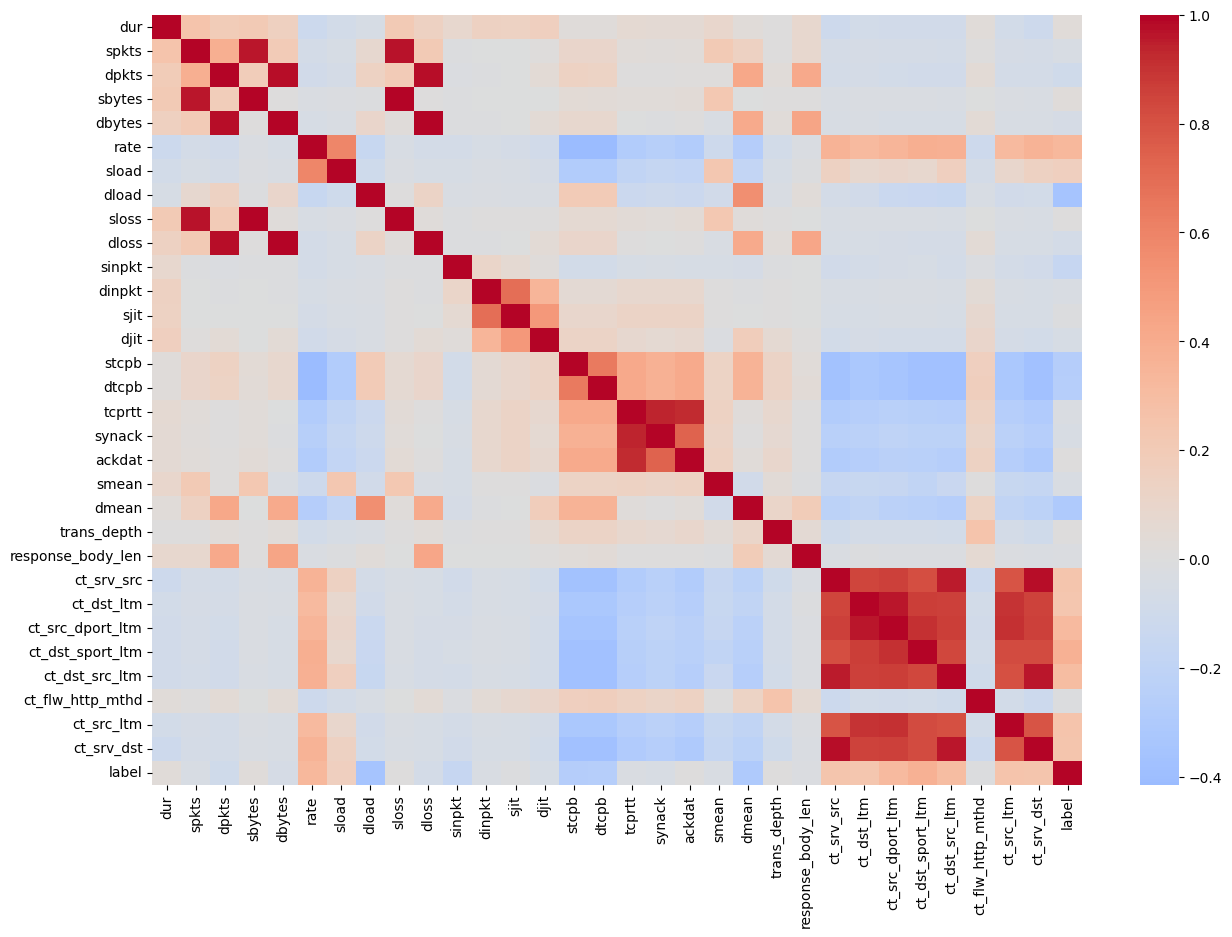

In [66]:
plt.figure(figsize=(15, 10))
sns.heatmap(df[numerical_features + ['label']].corr(), cmap='coolwarm', center=0)
plt.show()


from correlation matrix, we can conclude that some features can be reduntant like
- sbytes & spkts
- dbytes & dpkts
- all of counts
So we can drop some of them to keep the features clean and useful

the new shape:  (257647, 37)


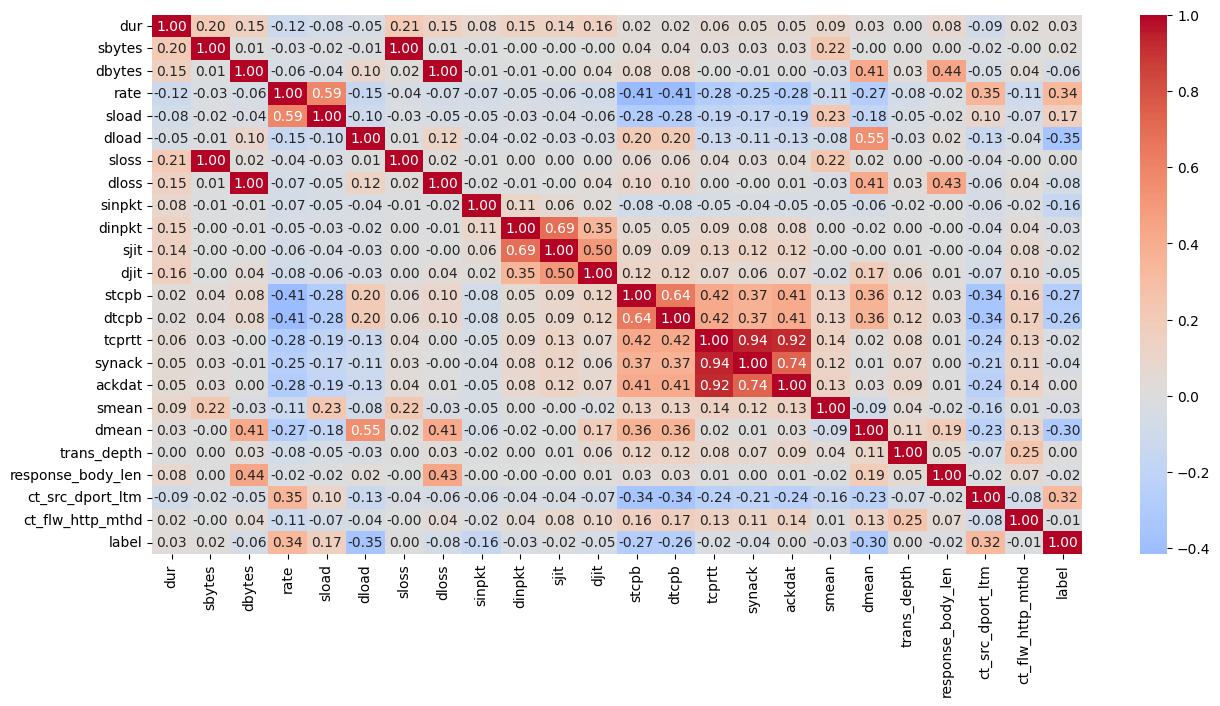

In [67]:
print("""
from correlation matrix, we can conclude that some features can be reduntant like
- sbytes & spkts
- dbytes & dpkts
- all of counts
So we can drop some of them to keep the features clean and useful
""")

drop_features = ['spkts', 'dpkts', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src']
clean_important_numerical_features = ['sbytes', 'dbytes', 'ct_src_dport_ltm']
numerical_features = [feature for feature in numerical_features if feature not in drop_features]
df = df.drop(columns=drop_features)
print("the new shape: ", df.shape)

numerical_features_corr = df[numerical_features + ['label']].corr()
plt.figure(figsize=(15, 7))
sns.heatmap(numerical_features_corr, cmap='coolwarm', annot=True, fmt='0.2f', center=0)
plt.show()

In [68]:
print("""
- Are there pairs of features with correlation close to +1?
Yes
- Are there pairs with correlation close to -1?
No
- Are there groups of highly correlated features?
Yes
- Are there signs of multicollinearity?
Yes
- Which features have the strongest correlation with label?
  - numerical: dload, rate, ct_src_dport_ltm, sload
""")


- Are there pairs of features with correlation close to +1?
Yes
- Are there pairs with correlation close to -1?
No
- Are there groups of highly correlated features?
Yes
- Are there signs of multicollinearity?
Yes
- Which features have the strongest correlation with label?
  - numerical: dload, rate, ct_src_dport_ltm, sload



In [69]:
df.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'sbytes', 'dbytes', 'rate',
       'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt',
       'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack',
       'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len',
       'ct_state_ttl', 'ct_src_dport_ltm', 'is_ftp_login', 'ct_ftp_cmd',
       'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

## Numerical vs categorical
- Does the distribution of sbytes differ by protocol?
- Does rate differ by protocol?
- Does dur differ by service?
- Does connection state differ between Normal and Attack?
- Which protocols are most associated with attacks?
- Which services are most associated with attacks?
- Which states are most associated with attacks?
- Does a particular protocol dominate a particular attack category?

## Outlier investigation
- Which features contain extreme values?
- Are these extreme values errors or legitimate network behavior?
- Are outliers concentrated in attacks?
- Are outliers concentrated in specific attack categories?
- Does removing extreme values significantly change the distribution?
- Could extreme values actually be useful for detecting attacks?

## Questions specifically useful for ML
- Is the target class balanced?
- Which features have potential predictive power?
- Which features have very low variance?
- Which features are highly correlated and potentially redundant?
- Are there categorical features that need encoding?
- Are numerical features on very different scales?
- Are there features that could cause data leakage?
- Are some attack classes too rare for reliable classification?
- Which features should potentially be transformed?
- Which features might require special treatment because of extreme skewness?

# Detection Model

## Our features

In [70]:
print(numerical_features)
categorical_features = categorical_features[0]
print(categorical_features)

['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_flw_http_mthd']
['proto', 'service', 'state', 'attack_cat', 'sttl', 'dttl', 'swin', 'dwin', 'ct_state_ttl', 'ct_ftp_cmd']


In [71]:
feature = numerical_features + categorical_features + binary_categorical_features
feature

['dur',
 'sbytes',
 'dbytes',
 'rate',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'stcpb',
 'dtcpb',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_src_dport_ltm',
 'ct_flw_http_mthd',
 'proto',
 'service',
 'state',
 'attack_cat',
 'sttl',
 'dttl',
 'swin',
 'dwin',
 'ct_state_ttl',
 'ct_ftp_cmd',
 'label',
 'is_ftp_login',
 'is_sm_ips_ports']

## Split features and label

In [72]:
X = df.drop(columns=['id', 'label', 'attack_cat'])
y = df[['label', 'attack_cat']]
print(df.shape)
print(X.shape)
print(y.shape)
print(y.columns)

(257647, 37)
(257647, 34)
(257647, 2)
Index(['label', 'attack_cat'], dtype='object')


## Split training and testing

In [73]:
from sklearn.model_selection import train_test_split
X_training, X_testing, y_training, y_testing = train_test_split(X, y['label'], test_size = 0.2, random_state=42, stratify=y['label'])
print(X_training.shape)
print(y_training.shape)
print(X_testing.shape)
print(y_testing.shape)

(206117, 34)
(206117,)
(51530, 34)
(51530,)


## Encode the categorical features

In [74]:
from sklearn.preprocessing import OneHotEncoder
detection_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

detection_categorical_features = [f for f in categorical_features if f != 'attack_cat']
categorical_features_encoded_training = detection_encoder.fit_transform(X=X_training[detection_categorical_features])
categorical_features_encoded_testing = detection_encoder.transform(X=X_testing[detection_categorical_features])

detection_encoding_cols = detection_encoder.get_feature_names_out(detection_categorical_features)
categorical_features_encoded_training = pd.DataFrame(categorical_features_encoded_training, index = X_training.index, columns=detection_encoding_cols)
categorical_features_encoded_testing = pd.DataFrame(categorical_features_encoded_testing, index = X_testing.index, columns=detection_encoding_cols)

X_training = X_training.drop(columns=detection_categorical_features)
X_testing = X_testing.drop(columns=detection_categorical_features)

X_training = pd.concat([X_training, categorical_features_encoded_training], axis=1)
X_testing = pd.concat([X_testing, categorical_features_encoded_testing], axis=1)

print(X_training.columns)
print(X_training.shape)
print(X_testing.columns)
print(X_testing.shape)

Index(['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt',
       ...
       'swin_moderate', 'dwin_high', 'dwin_low', 'dwin_moderate',
       'ct_state_ttl_high', 'ct_state_ttl_low', 'ct_state_ttl_moderate',
       'ct_ftp_cmd_0', 'ct_ftp_cmd_1', 'ct_ftp_cmd_2'],
      dtype='object', length=199)
(206117, 199)
Index(['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt',
       ...
       'swin_moderate', 'dwin_high', 'dwin_low', 'dwin_moderate',
       'ct_state_ttl_high', 'ct_state_ttl_low', 'ct_state_ttl_moderate',
       'ct_ftp_cmd_0', 'ct_ftp_cmd_1', 'ct_ftp_cmd_2'],
      dtype='object', length=199)
(51530, 199)


## Scaling

In [75]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_training[numerical_features] = scaler.fit_transform(X_training[numerical_features])
X_testing[numerical_features] = scaler.transform(X_testing[numerical_features])

## Build Model

In [76]:
from xgboost import XGBClassifier
detection_model = XGBClassifier(
    n_estimators = 100,
    max_depth = 10,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

In [77]:
detection_model.fit(X_training, y_training)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [78]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = detection_model.predict(X_testing)
print(accuracy_score(y_testing, y_pred))
print(classification_report(y_testing, y_pred))

0.938754123811372
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     18600
           1       0.96      0.94      0.95     32930

    accuracy                           0.94     51530
   macro avg       0.93      0.94      0.93     51530
weighted avg       0.94      0.94      0.94     51530



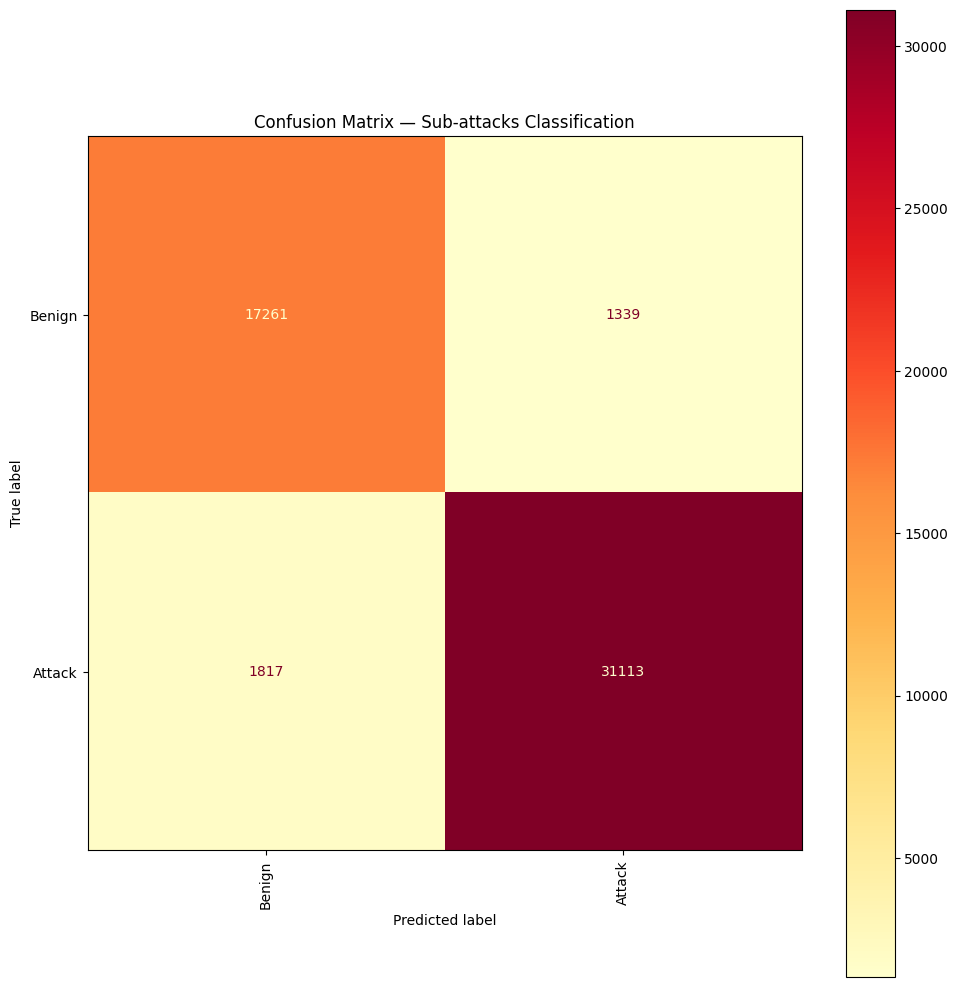

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_testing, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= ['Benign', 'Attack'])
disp.plot(cmap='YlOrRd', values_format='d', ax=ax, xticks_rotation=90, colorbar=True)
plt.title('Confusion Matrix — Sub-attacks Classification')
plt.tight_layout()
plt.show()

# Classification Model

In [83]:
# df_copy = df[df['attack_cat'] != 'Normal']
# X = df_copy.drop(columns=['id', 'label', 'attack_cat'])
# y = df_copy[['label', 'attack_cat']]
# print(df_copy.shape)
# print(X.shape)
# print(y.shape)
# print(y.columns)


df_copy = df[df['attack_cat'] != 'Normal'].copy()  # .copy() also fixes the earlier SettingWithCopyWarning

attack_group_map = {
    'Analysis': 'DoS_family',
    'Backdoor': 'DoS_family',
    'DoS': 'DoS_family',
    'Exploits': 'DoS_family',
    'Fuzzers': 'Fuzzers',
    'Generic': 'Generic',
    'Reconnaissance': 'Reconnaissance',
    'Shellcode': 'Shellcode',
    'Worms': 'Worms'
}
df_copy['attack_group'] = df_copy['attack_cat'].map(attack_group_map)

X = df_copy.drop(columns=['id', 'label', 'attack_cat', 'attack_group'])  # exclude attack_group too
y = df_copy[['label', 'attack_group']]  # target is now attack_group, not the old label/attack_cat pair

print(df_copy.shape)
print(X.shape)
print(y.shape)
print(y.value_counts())

(164649, 38)
(164649, 34)
(164649, 2)
label  attack_group  
1      DoS_family        65864
       Generic           58871
       Fuzzers           24242
       Reconnaissance    13987
       Shellcode          1511
       Worms               174
Name: count, dtype: int64


In [84]:
from sklearn.model_selection import train_test_split
X_training, X_testing, y_training, y_testing = train_test_split(X, y['attack_group'], test_size = 0.2, random_state=42, stratify=y['attack_group'])
print(X_training.shape)
print(y_training.shape)
print(X_testing.shape)
print(y_testing.shape)

(131719, 34)
(131719,)
(32930, 34)
(32930,)


In [85]:
from sklearn.preprocessing import OneHotEncoder
classification_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

classification_categorical_features = [f for f in categorical_features if f != 'attack_cat']
categorical_features_encoded_training = classification_encoder.fit_transform(X=X_training[classification_categorical_features])
categorical_features_encoded_testing = classification_encoder.transform(X=X_testing[classification_categorical_features])

classification_encoding_cols = classification_encoder.get_feature_names_out(classification_categorical_features)
categorical_features_encoded_training = pd.DataFrame(categorical_features_encoded_training, index = X_training.index, columns=classification_encoding_cols)
categorical_features_encoded_testing = pd.DataFrame(categorical_features_encoded_testing, index = X_testing.index, columns=classification_encoding_cols)

X_training = X_training.drop(columns=classification_categorical_features)
X_testing = X_testing.drop(columns=classification_categorical_features)

X_training = pd.concat([X_training, categorical_features_encoded_training], axis=1)
X_testing = pd.concat([X_testing, categorical_features_encoded_testing], axis=1)

print(X_training.columns)
print(X_training.shape)
print(X_testing.columns)
print(X_testing.shape)

Index(['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt',
       ...
       'dttl_moderate', 'swin_high', 'swin_low', 'dwin_high', 'dwin_low',
       'ct_state_ttl_high', 'ct_state_ttl_low', 'ct_state_ttl_moderate',
       'ct_ftp_cmd_0', 'ct_ftp_cmd_1'],
      dtype='object', length=188)
(131719, 188)
Index(['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt',
       ...
       'dttl_moderate', 'swin_high', 'swin_low', 'dwin_high', 'dwin_low',
       'ct_state_ttl_high', 'ct_state_ttl_low', 'ct_state_ttl_moderate',
       'ct_ftp_cmd_0', 'ct_ftp_cmd_1'],
      dtype='object', length=188)
(32930, 188)


In [86]:
from sklearn.preprocessing import LabelEncoder
classification_encoder_target = LabelEncoder()
y_training = classification_encoder_target.fit_transform(y_training)
y_testing = classification_encoder_target.transform(y_testing)

## Scaling

In [87]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_training[numerical_features] = scaler.fit_transform(X_training[numerical_features])
X_testing[numerical_features] = scaler.transform(X_testing[numerical_features])

In [88]:
from xgboost import XGBClassifier
classification_model = XGBClassifier(
    n_estimators = 200,
    max_depth = 10,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

In [89]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_training)
classification_model.fit(X_training, y_training, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [90]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = classification_model.predict(X_testing)
print(accuracy_score(y_testing, y_pred))
print(classification_report(y_testing, y_pred))

0.9269055572426359
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     13173
           1       0.90      0.84      0.87      4849
           2       1.00      0.98      0.99     11774
           3       0.86      0.81      0.84      2797
           4       0.52      0.89      0.65       302
           5       0.57      0.86      0.68        35

    accuracy                           0.93     32930
   macro avg       0.79      0.89      0.83     32930
weighted avg       0.93      0.93      0.93     32930



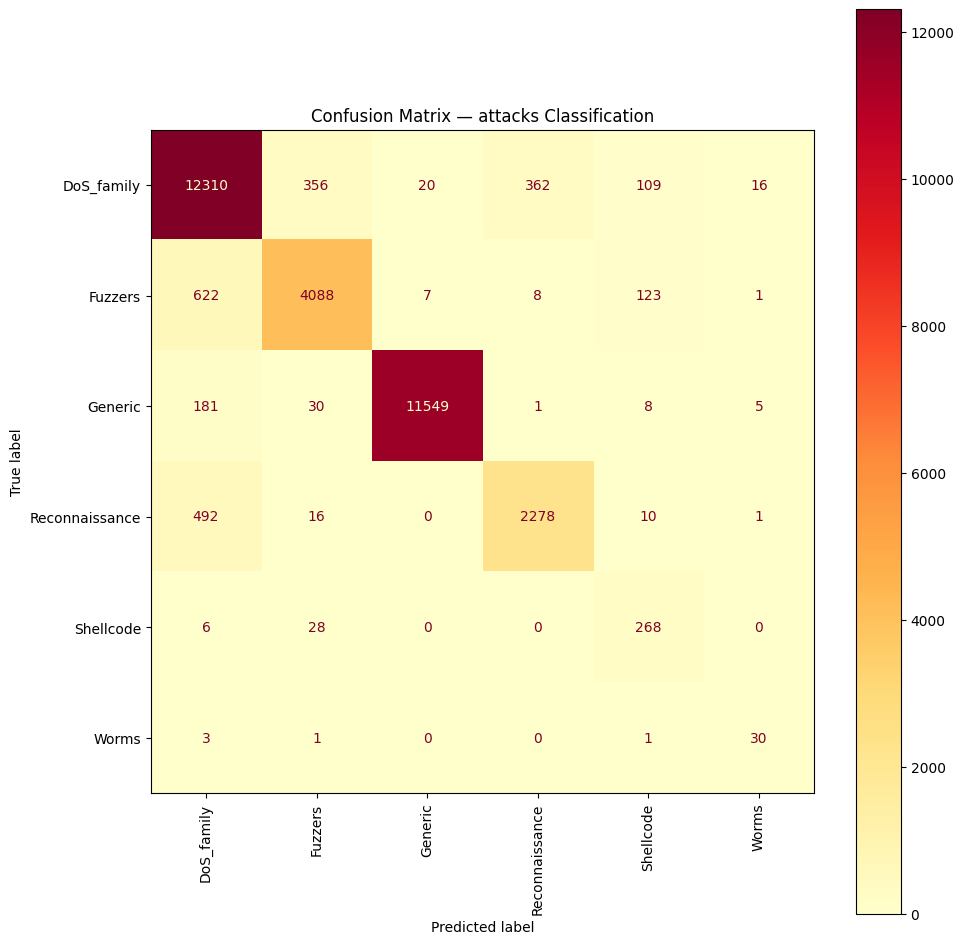

In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_testing, y_pred)
labels = classification_encoder_target.classes_
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='YlOrRd', values_format='d', ax=ax, xticks_rotation=90, colorbar=True)
plt.title('Confusion Matrix — attacks Classification')
plt.tight_layout()
plt.show()

# Dos_falmily Model

In [93]:
# Step 1: Filter to only the 4 confused categories, from the ORIGINAL df (not df_copy which already merged them)
dos_family_categories = ['Analysis', 'Backdoor', 'DoS', 'Exploits']
df_dos_family = df[df['attack_cat'].isin(dos_family_categories)].copy()

print(df_dos_family.shape)
print(df_dos_family['attack_cat'].value_counts())

(65864, 37)
attack_cat
Exploits    44505
DoS         16353
Analysis     2677
Backdoor     2329
Name: count, dtype: int64


In [94]:
# Step 2: Build X, y for this sub-model
X_dos = df_dos_family.drop(columns=['id', 'label', 'attack_cat'])
y_dos = df_dos_family['attack_cat']

print(X_dos.shape, y_dos.shape)

(65864, 34) (65864,)


In [95]:
# Step 3: Split
from sklearn.model_selection import train_test_split
X_dos_training, X_dos_testing, y_dos_training, y_dos_testing = train_test_split(
    X_dos, y_dos, test_size=0.2, random_state=42, stratify=y_dos
)
print(X_dos_training.shape, X_dos_testing.shape)

(52691, 34) (13173, 34)


In [96]:
# Step 4: Encode categoricals (same pattern as before)
from sklearn.preprocessing import OneHotEncoder
dos_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
dos_categorical_features = [f for f in categorical_features if f != 'attack_cat']

cat_train_encoded = dos_encoder.fit_transform(X_dos_training[dos_categorical_features])
cat_test_encoded = dos_encoder.transform(X_dos_testing[dos_categorical_features])

dos_encoding_cols = dos_encoder.get_feature_names_out(dos_categorical_features)
cat_train_encoded = pd.DataFrame(cat_train_encoded, index=X_dos_training.index, columns=dos_encoding_cols)
cat_test_encoded = pd.DataFrame(cat_test_encoded, index=X_dos_testing.index, columns=dos_encoding_cols)

X_dos_training = X_dos_training.drop(columns=dos_categorical_features)
X_dos_testing = X_dos_testing.drop(columns=dos_categorical_features)
X_dos_training = pd.concat([X_dos_training, cat_train_encoded], axis=1)
X_dos_testing = pd.concat([X_dos_testing, cat_test_encoded], axis=1)

print(X_dos_training.isnull().sum().sum(), X_dos_testing.isnull().sum().sum())

0 0


In [97]:
# Step 5: Encode target
from sklearn.preprocessing import LabelEncoder
dos_target_encoder = LabelEncoder()
y_dos_training = dos_target_encoder.fit_transform(y_dos_training)
y_dos_testing = dos_target_encoder.transform(y_dos_testing)

print(dict(zip(range(len(dos_target_encoder.classes_)), dos_target_encoder.classes_)))

{0: 'Analysis', 1: 'Backdoor', 2: 'DoS', 3: 'Exploits'}


In [98]:
# Step 6: Fit with class weighting (Analysis/Backdoor are much smaller than DoS/Exploits)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

sample_weights = compute_sample_weight(class_weight='balanced', y=y_dos_training)

dos_submodel = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=4,
    eval_metric='mlogloss', random_state=42
)
dos_submodel.fit(X_dos_training, y_dos_training, sample_weight=sample_weights)

y_dos_pred = dos_submodel.predict(X_dos_testing)
print(accuracy_score(y_dos_testing, y_dos_pred))
print(classification_report(y_dos_testing, y_dos_pred))

0.5653230091854551
              precision    recall  f1-score   support

           0       0.15      0.26      0.19       535
           1       0.08      0.35      0.12       466
           2       0.41      0.56      0.47      3271
           3       0.93      0.60      0.73      8901

    accuracy                           0.57     13173
   macro avg       0.39      0.44      0.38     13173
weighted avg       0.74      0.57      0.62     13173



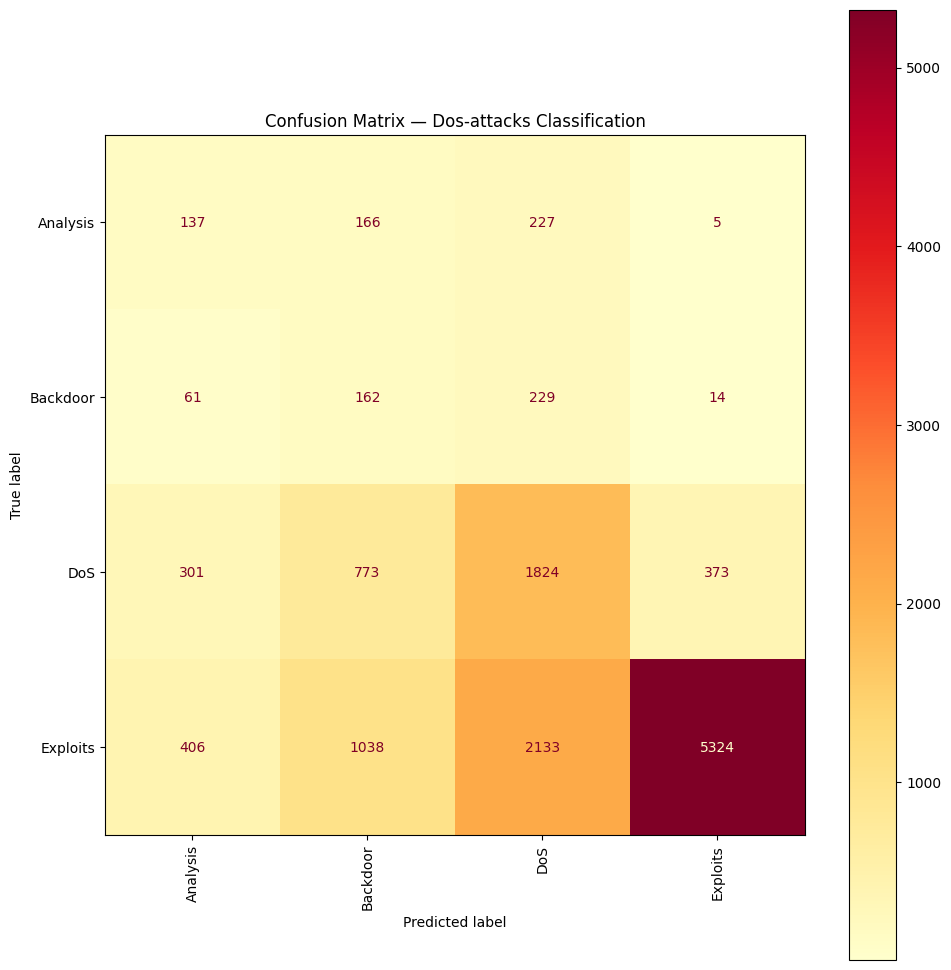

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_dos_testing, y_dos_pred)
labels = dos_target_encoder.classes_
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='YlOrRd', values_format='d', ax=ax, xticks_rotation=90, colorbar=True)
plt.title('Confusion Matrix — Dos-attacks Classification')
plt.tight_layout()
plt.show()